In [2]:
import pandas as pd
import mat73
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums, sem
import seaborn as sns
from itertools import combinations


def unwrap_matlab_scalars(df, columns):
    # mat73 sometimes loads MATLAB scalar/missing double values as 0-d or
    # empty numpy arrays instead of plain floats/NaN. This unwraps each
    # array-typed cell to its scalar value (or NaN if the array is empty),
    # so pandas operations like .mean() work correctly on the whole column
    # instead of silently returning NaN for the entire group.
    for col in columns:
        cleaned_values = []
        for v in df[col]:
            if isinstance(v, np.ndarray):
                if v.size == 0:
                    cleaned_values.append(np.nan)
                else:
                    cleaned_values.append(float(v.flatten()[0]))
            else:
                cleaned_values.append(v)
        df[col] = pd.Series(cleaned_values, index=df.index, dtype=float)
    return df


In [3]:
base_path = r"C:\Users\fkamdar\Desktop\repos\data\pd_beh_data\pdnm091_beh_data"

subj = 'pdnm091'
condition1 = 'ONmed_ONstimDorsal'    # ses01
condition2 = 'OFFmed_ONstimDorsal'   # ses02
condition3 = 'OFFmed_ONstimVentral'  # ses03
condition4 = 'ONmed_OFFstim'         # ses04, split into block2 + block3
condition5 = 'OFFmed_OFFstim'        # ses05
condition6 = 'ONmed_ONstimVentral'   # ses06

mat_path1 = base_path + r"\Results_PDNM091_S1_C1_B2_2026-04-13.mat"
data1 = mat73.loadmat(mat_path1)

mat_path2 = base_path + r"\Results_PDNM091_S2_C2_B2_2026-04-27.mat"
data2 = mat73.loadmat(mat_path2)

mat_path3 = base_path + r"\Results_PDNM091_S3_C3_B2_2026-06-30.mat"
data3 = mat73.loadmat(mat_path3)

mat_path4_block2 = base_path + r"\Results_PDNM091_S4_C4_B2_2026-07-09.mat"
data4_block2 = mat73.loadmat(mat_path4_block2)

mat_path4_block3 = base_path + r"\Results_PDNM091_S4_C4_B3_2026-07-09.mat"
data4_block3 = mat73.loadmat(mat_path4_block3)

mat_path5 = base_path + r"\Results_PDNM091_S5_C5_B2_2026-07-23.mat"
data5 = mat73.loadmat(mat_path5)

mat_path6 = base_path + r"\Results_PDNM091_S6_C6_B2_2026-07-29.mat"
data6 = mat73.loadmat(mat_path6)


In [4]:
manifest_ses01 = pd.read_csv(base_path + r"\PDNM091_session_1.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses02 = pd.read_csv(base_path + r"\PDNM091_session_2.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses03 = pd.read_csv(base_path + r"\PDNM091_session_3.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses04_block2 = pd.read_csv(base_path + r"\PDNM091_session_4_block2.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses04_block3 = pd.read_csv(base_path + r"\PDNM091_session_4_block3.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses05 = pd.read_csv(base_path + r"\PDNM091_session_5.csv").dropna(subset=['trial']).reset_index(drop=True)
manifest_ses06 = pd.read_csv(base_path + r"\PDNM091_session_6.csv").dropna(subset=['trial']).reset_index(drop=True)


In [5]:
# Session 4, Block 2
results_pdnm091_ses04_block2 = data4_block2['Results']  # adjust key name if needed
trials_pdnm091_ses04_block2 = pd.DataFrame(results_pdnm091_ses04_block2['Trials'])
trials_pdnm091_ses04_block2 = unwrap_matlab_scalars(trials_pdnm091_ses04_block2, ['RT_Valence', 'Valence'])

# Session 4, Block 3
results_pdnm091_ses04_block3 = data4_block3['Results']  # adjust key name if needed
trials_pdnm091_ses04_block3 = pd.DataFrame(results_pdnm091_ses04_block3['Trials'])
trials_pdnm091_ses04_block3 = unwrap_matlab_scalars(trials_pdnm091_ses04_block3, ['RT_Valence', 'Valence'])


# --- Manifests ---
trial_offset_manifest = len(manifest_ses04_block2)
manifest_ses04_block3['trial'] = manifest_ses04_block3['trial'] + trial_offset_manifest

manifest_ses04 = pd.concat([manifest_ses04_block2, manifest_ses04_block3], ignore_index=True)

# --- Trials (from .mat Results) ---
imageindex_offset_trials = len(trials_pdnm091_ses04_block2)
trials_pdnm091_ses04_block3['ImageIndex'] = trials_pdnm091_ses04_block3['ImageIndex'] + imageindex_offset_trials

trials_pdnm091_ses04 = pd.concat([trials_pdnm091_ses04_block2, trials_pdnm091_ses04_block3], ignore_index=True)

# sanity check
print(manifest_ses04.iloc[trial_offset_manifest-1 : trial_offset_manifest+1])
print(trials_pdnm091_ses04.iloc[imageindex_offset_trials-1 : imageindex_offset_trials+1])


    trial             ID           filename Category  Valence val_bin  \
55   56.0  Objects_235_h  Objects_235_h.jpg  Objects     3.96   4-Mar   
56   57.0  Objects_184_v  Objects_184_v.jpg  Objects     4.18   5-Apr   

   condition  
55      TONE  
56      FEEL  
   Condition      CueText ImageIndex  RT_Valence  Valence
55      TONE    Tone down       56.0    1.068242      3.0
56      FEEL  Feel freely       57.0    0.355929      2.0


In [6]:
# Session 1
results_pdnm091_ses01 = data1['Results']  # adjust key name if needed
trials_pdnm091_ses01 = pd.DataFrame(results_pdnm091_ses01['Trials'])
trials_pdnm091_ses01 = unwrap_matlab_scalars(trials_pdnm091_ses01, ['RT_Valence', 'Valence'])
trials_pdnm091_ses01['ImageIndex'] = trials_pdnm091_ses01['ImageIndex'].astype(int)
merged_df_ses01 = pd.merge(trials_pdnm091_ses01, manifest_ses01, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses01.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses01.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses01 = merged_df_ses01.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction',
    'ImageIndex': 'TrialNumber'
})
merged_df_ses01 = merged_df_ses01.dropna().reset_index(drop=True)  # drop any trial with a missing value

# Session 2
results_pdnm091_ses02 = data2['Results']  # adjust key name if needed
trials_pdnm091_ses02 = pd.DataFrame(results_pdnm091_ses02['Trials'])
trials_pdnm091_ses02 = unwrap_matlab_scalars(trials_pdnm091_ses02, ['RT_Valence', 'Valence'])
trials_pdnm091_ses02['ImageIndex'] = trials_pdnm091_ses02['ImageIndex'].astype(int)
merged_df_ses02 = pd.merge(trials_pdnm091_ses02, manifest_ses02, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses02.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses02.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses02 = merged_df_ses02.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction',
    'ImageIndex': 'TrialNumber'
})
merged_df_ses02 = merged_df_ses02.dropna().reset_index(drop=True)  # drop any trial with a missing value

# Session 3
results_pdnm091_ses03 = data3['Results']  # adjust key name if needed
trials_pdnm091_ses03 = pd.DataFrame(results_pdnm091_ses03['Trials'])
trials_pdnm091_ses03 = unwrap_matlab_scalars(trials_pdnm091_ses03, ['RT_Valence', 'Valence'])
trials_pdnm091_ses03['ImageIndex'] = trials_pdnm091_ses03['ImageIndex'].astype(int)
merged_df_ses03 = pd.merge(trials_pdnm091_ses03, manifest_ses03, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses03.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses03.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses03 = merged_df_ses03.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'ImageIndex': 'TrialNumber',
    'Condition': 'instruction'
})
merged_df_ses03 = merged_df_ses03.dropna().reset_index(drop=True)  # drop any trial with a missing value

# Session 4 (uses the concatenated trials_pdnm091_ses04 / manifest_ses04 built above)
trials_pdnm091_ses04['ImageIndex'] = trials_pdnm091_ses04['ImageIndex'].astype(int)
merged_df_ses04 = pd.merge(trials_pdnm091_ses04, manifest_ses04, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses04.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses04.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses04 = merged_df_ses04.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction',
    'ImageIndex': 'TrialNumber'
})
merged_df_ses04 = merged_df_ses04.dropna().reset_index(drop=True)  # drop any trial with a missing value

# Session 5
results_pdnm091_ses05 = data5['Results']  # adjust key name if needed
trials_pdnm091_ses05 = pd.DataFrame(results_pdnm091_ses05['Trials'])
trials_pdnm091_ses05 = unwrap_matlab_scalars(trials_pdnm091_ses05, ['RT_Valence', 'Valence'])
trials_pdnm091_ses05['ImageIndex'] = trials_pdnm091_ses05['ImageIndex'].astype(int)
merged_df_ses05 = pd.merge(trials_pdnm091_ses05, manifest_ses05, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses05.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses05.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses05 = merged_df_ses05.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction',
    'ImageIndex': 'TrialNumber'
})
merged_df_ses05 = merged_df_ses05.dropna().reset_index(drop=True)  # drop any trial with a missing value

# Session 6
results_pdnm091_ses06 = data6['Results']  # adjust key name if needed
trials_pdnm091_ses06 = pd.DataFrame(results_pdnm091_ses06['Trials'])
trials_pdnm091_ses06 = unwrap_matlab_scalars(trials_pdnm091_ses06, ['RT_Valence', 'Valence'])
trials_pdnm091_ses06['ImageIndex'] = trials_pdnm091_ses06['ImageIndex'].astype(int)
merged_df_ses06 = pd.merge(trials_pdnm091_ses06, manifest_ses06, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses06.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses06.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses06 = merged_df_ses06.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction',
    'ImageIndex': 'TrialNumber'
})
merged_df_ses06 = merged_df_ses06.dropna().reset_index(drop=True)  # drop any trial with a missing value


In [7]:
# Summary: how many trials were dropped per session due to missing RT/valence values
sessions_summary = [
    (condition1, merged_df_ses01, len(trials_pdnm091_ses01)),
    (condition2, merged_df_ses02, len(trials_pdnm091_ses02)),
    (condition3, merged_df_ses03, len(trials_pdnm091_ses03)),
    (condition4, merged_df_ses04, len(trials_pdnm091_ses04)),
    (condition5, merged_df_ses05, len(trials_pdnm091_ses05)),
    (condition6, merged_df_ses06, len(trials_pdnm091_ses06)),
]

for sess_label, df, n_total in sessions_summary:
    n_kept = len(df)
    n_dropped = n_total - n_kept
    print(f'{sess_label}: {n_kept}/{n_total} trials kept ({n_dropped} dropped for missing values)')


ONmed_ONstimDorsal: 111/112 trials kept (1 dropped for missing values)
OFFmed_ONstimDorsal: 112/112 trials kept (0 dropped for missing values)
OFFmed_ONstimVentral: 112/112 trials kept (0 dropped for missing values)
ONmed_OFFstim: 103/112 trials kept (9 dropped for missing values)
OFFmed_OFFstim: 110/112 trials kept (2 dropped for missing values)
ONmed_ONstimVentral: 112/112 trials kept (0 dropped for missing values)


In [8]:
def plot_valence_vs_normative(merged_df, condition, subj, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    normative_ratings = merged_df['normative_rating'].values
    valence_ratings = merged_df['participant_rating'].values
    normative_ratings = pd.to_numeric(pd.Series(normative_ratings), errors='coerce').to_numpy(dtype=float)
    valence_ratings = pd.to_numeric(pd.Series(valence_ratings), errors='coerce').to_numpy(dtype=float)

    mask = ~np.isnan(normative_ratings) & ~np.isnan(valence_ratings)
    num_valence_nans = np.isnan(valence_ratings).sum()
    norm_vals_clean = normative_ratings[mask]
    valence_clean = valence_ratings[mask]

    ax.scatter(norm_vals_clean, valence_clean, alpha=0.7)

    coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
    fit_fn = np.poly1d(coeffs)
    x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)

    ax.plot(x_fit, fit_fn(x_fit), color='red', linewidth=2, label='Linear fit')
    ax.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
    ax.legend(loc='upper left', bbox_to_anchor=(0, 1))
    ax.set_xlabel('Normative Ratings')
    ax.set_ylabel('Valence Ratings')
    ax.set_title(f'{condition} {subj} Valence Ratings')
    ax.set_xticks(np.arange(1, 10, 1))
    ax.set_yticks(np.arange(1, 10, 1))
    ax.set_xlim(1, 9)
    ax.set_ylim(0, 10)
    ax.grid(True)

    return ax


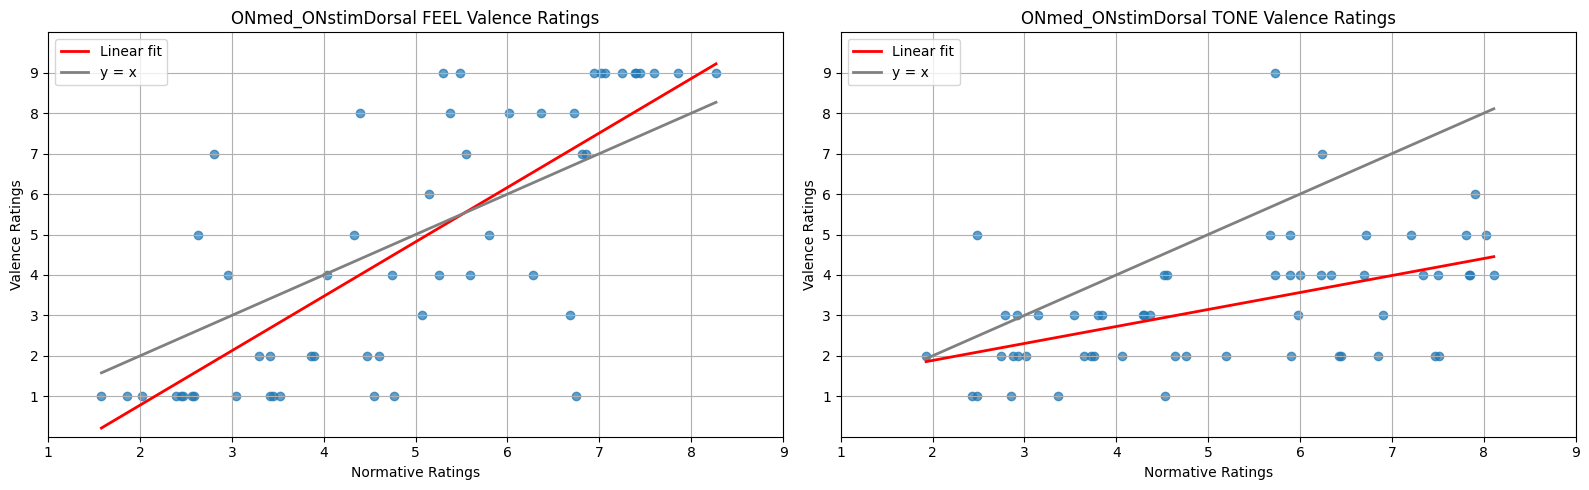

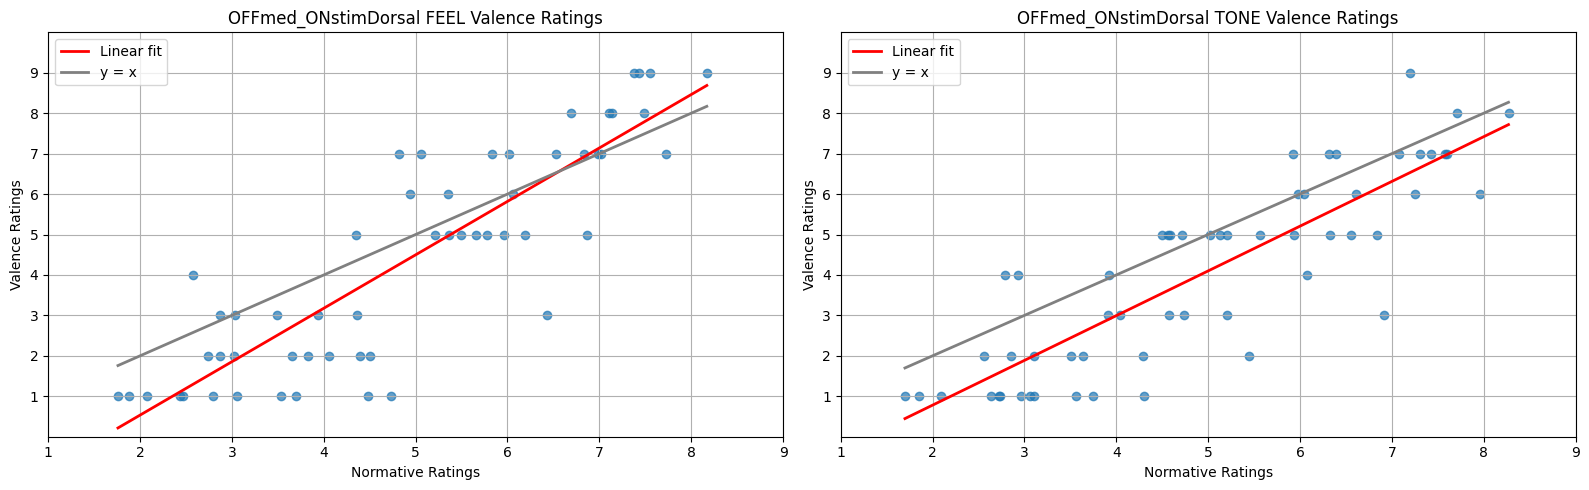

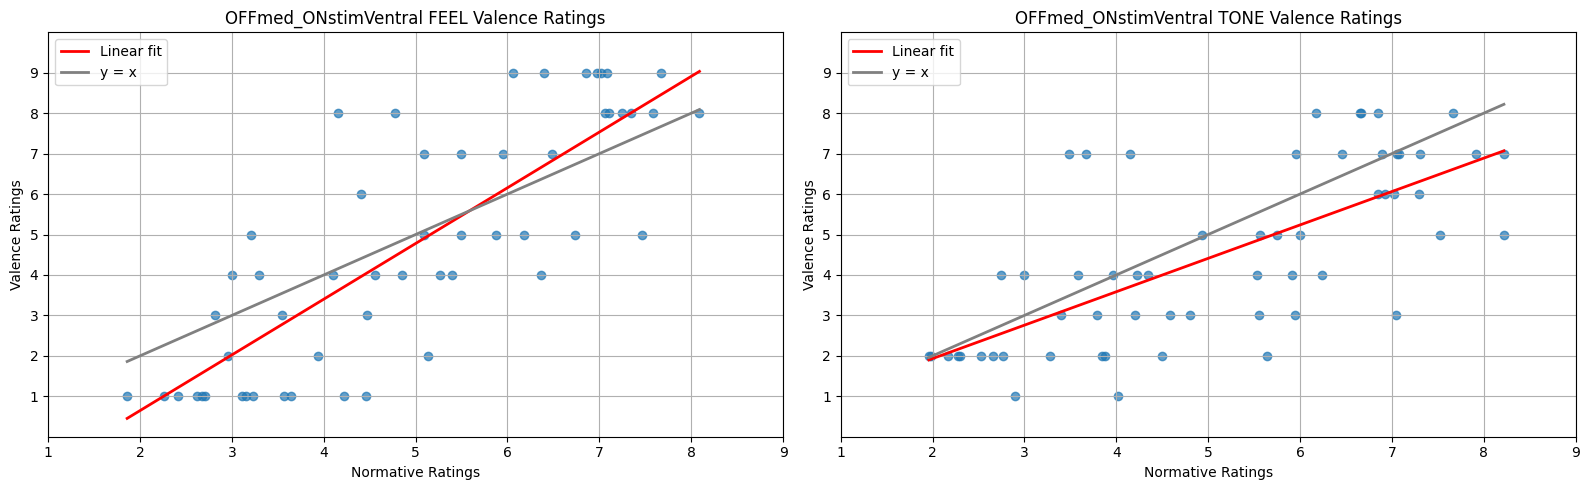

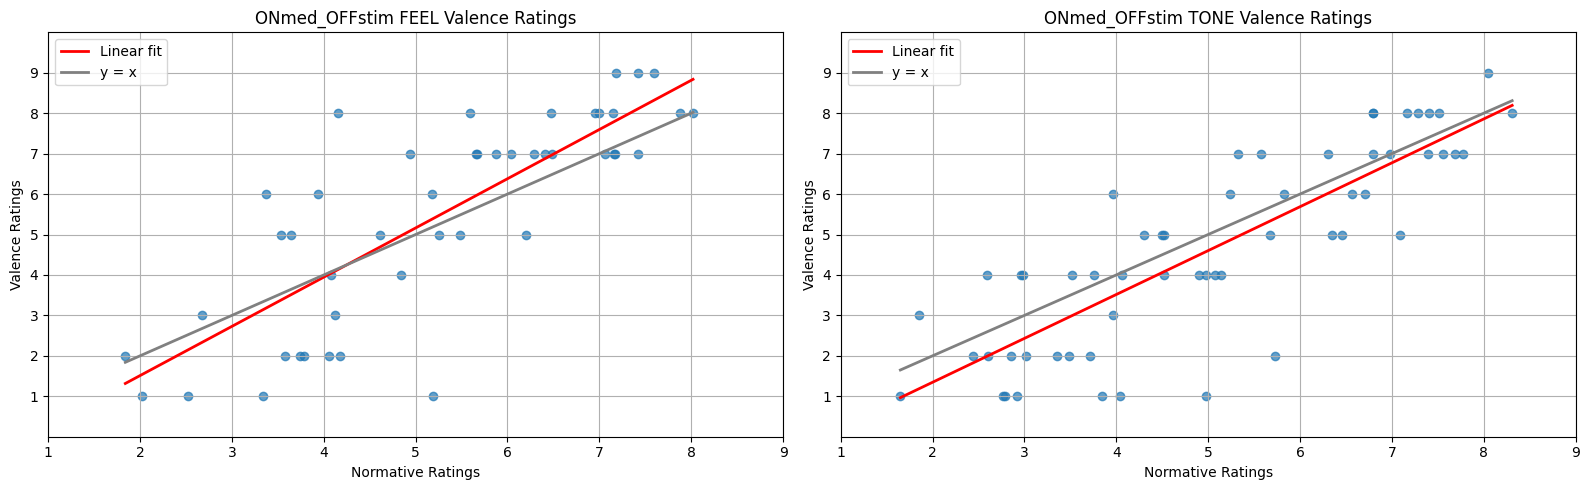

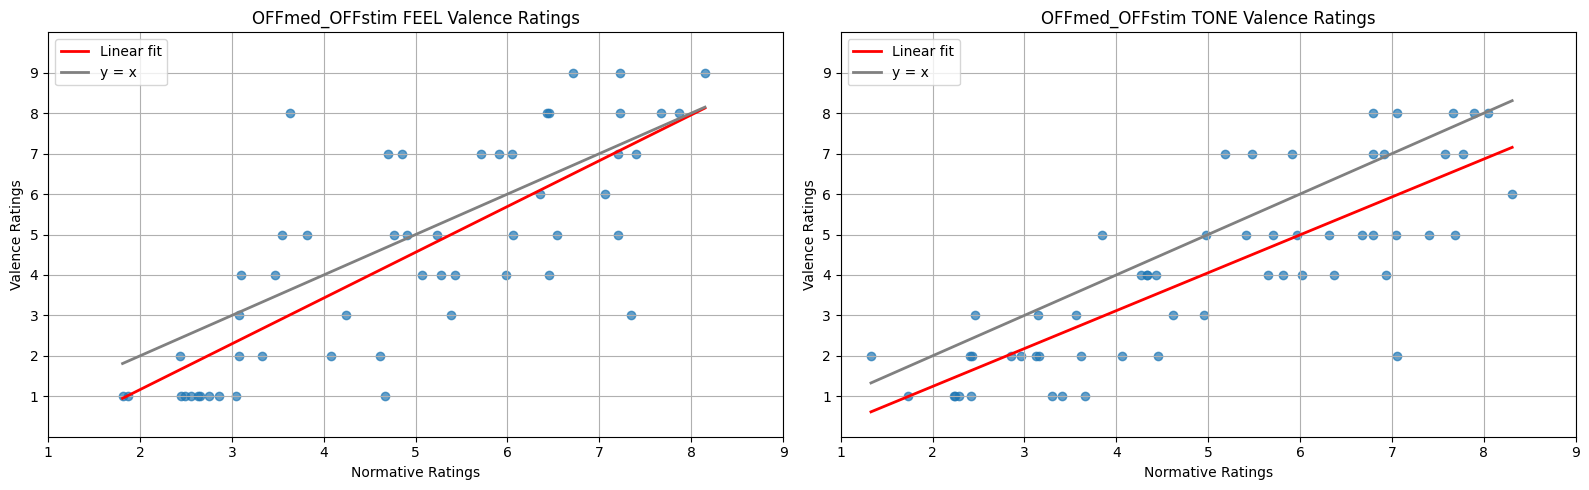

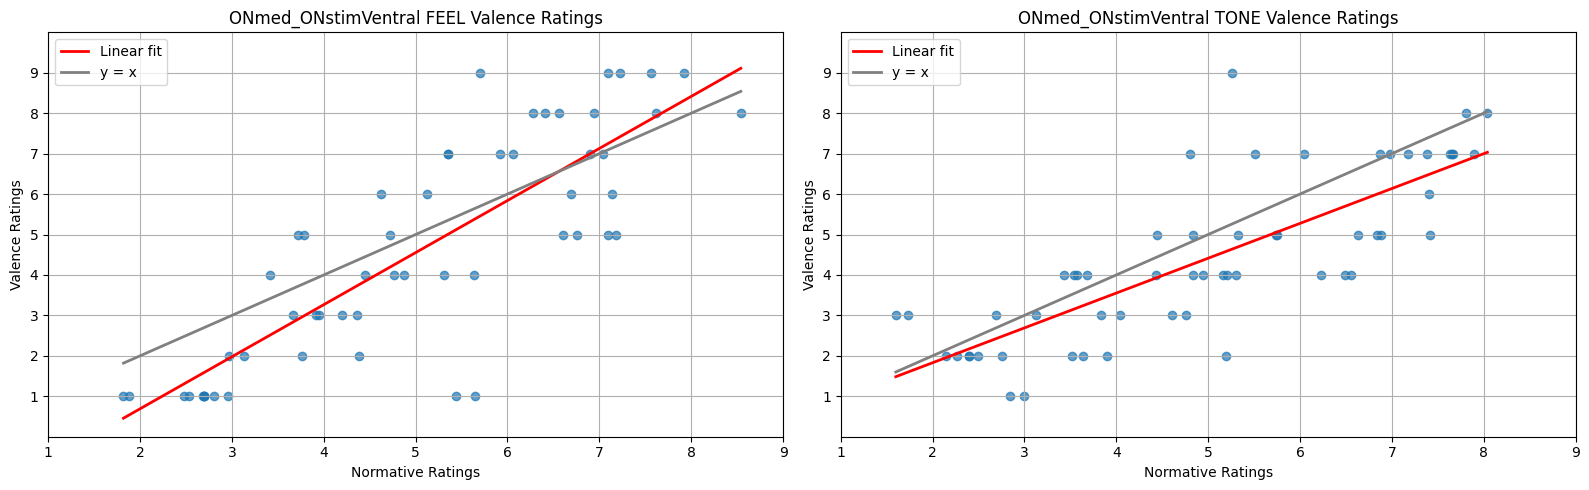

In [9]:
sessions = [
    (condition1, merged_df_ses01),
    (condition2, merged_df_ses02),
    (condition3, merged_df_ses03),
    (condition4, merged_df_ses04),
    (condition5, merged_df_ses05),
    (condition6, merged_df_ses06),
]

for sess_label, df in sessions:
    feel_trials = df[df['instruction'] == 'FEEL']
    tone_trials = df[df['instruction'] == 'TONE']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_valence_vs_normative(feel_trials, sess_label, 'FEEL', ax=axes[0])
    plot_valence_vs_normative(tone_trials, sess_label, 'TONE', ax=axes[1])
    plt.tight_layout()
    plt.show()


In [10]:
cue_types = {'FEEL', 'TONE'}
cue_types = list({'FEEL', 'TONE'})
print(cue_types[0])
print(cue_types[1])


FEEL
TONE


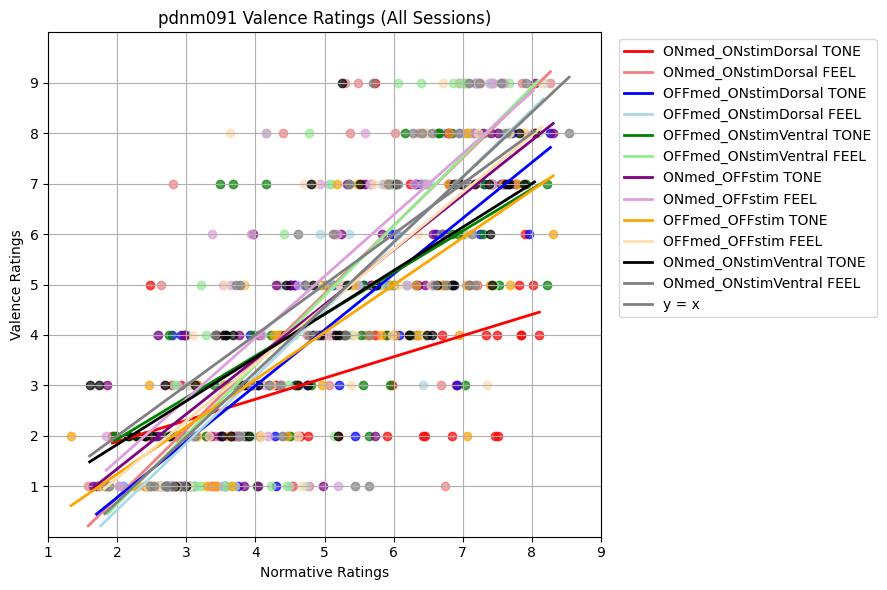

In [11]:
# Config: session dataframes, labels, and color pairs (feel color, tone color)
session_dfs = [merged_df_ses01, merged_df_ses02, merged_df_ses03, merged_df_ses04, merged_df_ses05, merged_df_ses06]
condition_labels = [condition1, condition2, condition3, condition4, condition5, condition6]
session_colors = [
    ('red', 'lightcoral'),
    ('blue', 'lightblue'),
    ('green', 'lightgreen'),
    ('purple', 'plum'),
    ('orange', 'navajowhite'),
    ('black', 'gray'),
]

fig, ax = plt.subplots(figsize=(9, 6))

for i in range(len(session_dfs)):
    merged_df = session_dfs[i]
    condition_label = condition_labels[i]
    feel_color, tone_color = session_colors[i]

    feel_trials = merged_df[merged_df['instruction'] == cue_types[1]]
    tone_trials = merged_df[merged_df['instruction'] == cue_types[0]]

    # Feel trials
    normative_ratings = feel_trials['normative_rating'].values
    valence_ratings = feel_trials['participant_rating'].values
    normative_ratings = pd.to_numeric(pd.Series(normative_ratings), errors='coerce').to_numpy(dtype=float)
    valence_ratings = pd.to_numeric(pd.Series(valence_ratings), errors='coerce').to_numpy(dtype=float)
    mask = ~np.isnan(normative_ratings) & ~np.isnan(valence_ratings)
    norm_vals_clean = normative_ratings[mask]
    valence_clean = valence_ratings[mask]

    # Tone trials
    tone_normative_ratings = tone_trials['normative_rating'].values
    tone_valence_ratings = tone_trials['participant_rating'].values
    tone_normative_ratings = pd.to_numeric(pd.Series(tone_normative_ratings), errors='coerce').to_numpy(dtype=float)
    tone_valence_ratings = pd.to_numeric(pd.Series(tone_valence_ratings), errors='coerce').to_numpy(dtype=float)
    tone_mask = ~np.isnan(tone_normative_ratings) & ~np.isnan(tone_valence_ratings)
    tone_norm_vals_clean = tone_normative_ratings[tone_mask]
    tone_valence_clean = tone_valence_ratings[tone_mask]

    # Feel
    ax.scatter(norm_vals_clean, valence_clean, alpha=0.7, color=feel_color)
    coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
    fit_fn = np.poly1d(coeffs)
    x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)
    ax.plot(x_fit, fit_fn(x_fit), color=feel_color, linewidth=2, label=f'{condition_label} {cue_types[1]}')

    # Tone
    ax.scatter(tone_norm_vals_clean, tone_valence_clean, alpha=0.7, color=tone_color)
    tone_coeffs = np.polyfit(tone_norm_vals_clean, tone_valence_clean, 1)
    tone_fit_fn = np.poly1d(tone_coeffs)
    tone_x_fit = np.linspace(tone_norm_vals_clean.min(), tone_norm_vals_clean.max(), 100)
    ax.plot(tone_x_fit, tone_fit_fn(tone_x_fit), color=tone_color, linewidth=2, label=f'{condition_label} {cue_types[0]}')

ax.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_xlabel('Normative Ratings')
ax.set_ylabel('Valence Ratings')
ax.set_title(f'{subj} Valence Ratings (All Sessions)')
ax.set_xticks(np.arange(1, 10, 1))
ax.set_yticks(np.arange(1, 10, 1))
ax.set_xlim(1, 9)
ax.set_ylim(0, 10)
ax.grid(True)

plt.tight_layout()


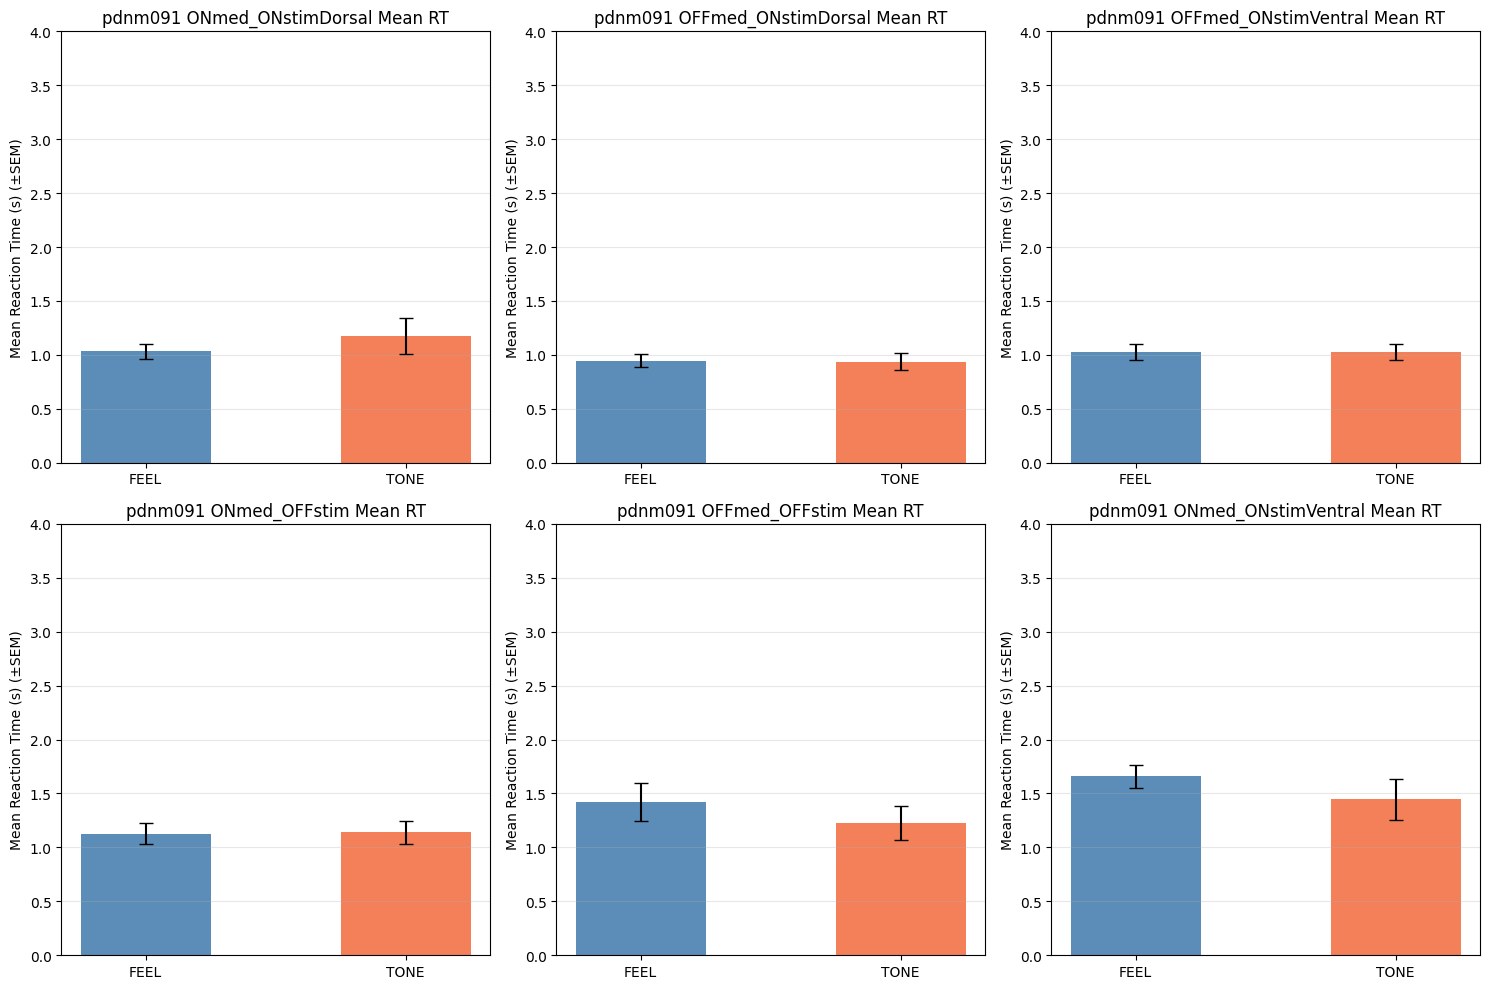

In [12]:
# plot mean +- sem reaction times for all feel and tone trials for all 6 sessions
mean_rt_feel_ses01 = merged_df_ses01[merged_df_ses01['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses01 = merged_df_ses01[merged_df_ses01['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses02 = merged_df_ses02[merged_df_ses02['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses02 = merged_df_ses02[merged_df_ses02['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses03 = merged_df_ses03[merged_df_ses03['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses03 = merged_df_ses03[merged_df_ses03['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses04 = merged_df_ses04[merged_df_ses04['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses04 = merged_df_ses04[merged_df_ses04['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses05 = merged_df_ses05[merged_df_ses05['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses05 = merged_df_ses05[merged_df_ses05['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses06 = merged_df_ses06[merged_df_ses06['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses06 = merged_df_ses06[merged_df_ses06['instruction'] == 'TONE']['RT_Valence'].mean()


def plot_rt_bar(merged_df, sess_label, ax):
    feel_rt = merged_df[merged_df['instruction'] == 'FEEL']['RT_Valence'].dropna()
    tone_rt = merged_df[merged_df['instruction'] == 'TONE']['RT_Valence'].dropna()

    means = [feel_rt.mean(), tone_rt.mean()]
    sems = [sem(feel_rt), sem(tone_rt)]

    ax.bar(['FEEL', 'TONE'], means, yerr=sems, capsize=5,
           color=['#5b8db8', '#f4805a'], width=0.5)

    ax.set_ylim(0, 4)
    ax.set_title(f'{subj} {sess_label} Mean RT')
    ax.set_ylabel('Mean Reaction Time (s) (±SEM)')
    ax.grid(True, axis='y', alpha=0.3)


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sessions = [
    (condition1, merged_df_ses01),
    (condition2, merged_df_ses02),
    (condition3, merged_df_ses03),
    (condition4, merged_df_ses04),
    (condition5, merged_df_ses05),
    (condition6, merged_df_ses06),
]

for (sess_label, df), ax in zip(sessions, axes):
    plot_rt_bar(df, sess_label, ax)

plt.tight_layout()
plt.show()


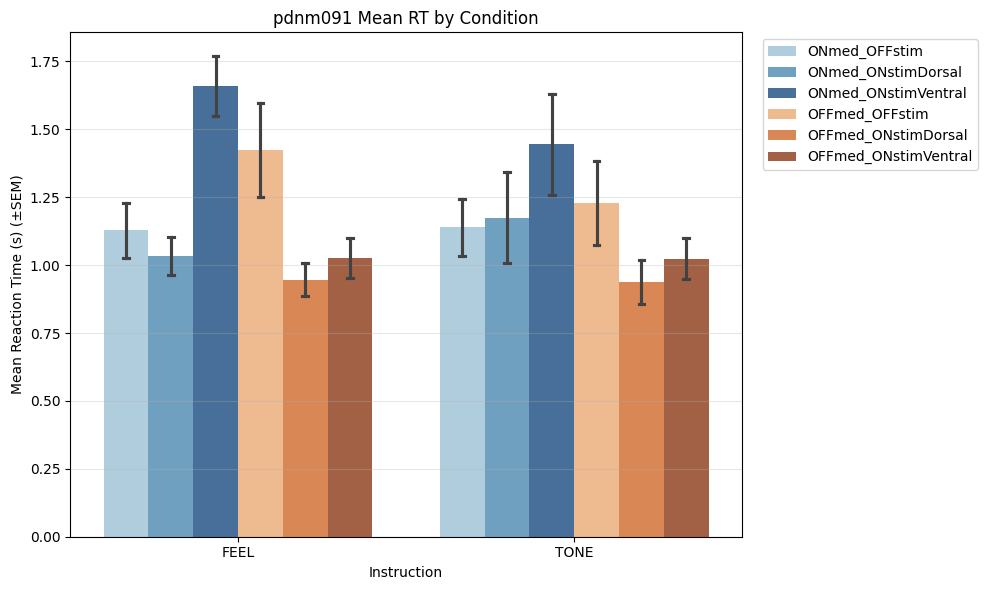

In [17]:
rt_df = pd.concat([
    merged_df_ses01[['instruction', 'RT_Valence']].assign(condition=condition1),
    merged_df_ses02[['instruction', 'RT_Valence']].assign(condition=condition2),
    merged_df_ses03[['instruction', 'RT_Valence']].assign(condition=condition3),
    merged_df_ses04[['instruction', 'RT_Valence']].assign(condition=condition4),
    merged_df_ses05[['instruction', 'RT_Valence']].assign(condition=condition5),
    merged_df_ses06[['instruction', 'RT_Valence']].assign(condition=condition6),
], ignore_index=True)

condition_order_rt = [condition4, condition1, condition6, condition5, condition2, condition3]
condition_colors_rt = ['#94c4df', '#3b8bc2', '#084a91', '#fda762', '#ec620f', '#9e3303']
cue_order = ['FEEL', 'TONE']

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=rt_df, x='instruction', y='RT_Valence', hue='condition',
    order=cue_order, hue_order=condition_order_rt, palette=condition_colors_rt,
    errorbar='se', capsize=0.1, alpha=0.8, ax=ax
)

ax.set_xlabel('Instruction')
ax.set_ylabel('Mean Reaction Time (s) (±SEM)')
ax.set_title(f'{subj} Mean RT by Condition')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

              condition  n_feel  n_tone  statistic   p_value stars
0         ONmed_OFFstim      46      57   0.139308  0.889207      
1    ONmed_ONstimDorsal      54      57  -0.483795  0.628532      
2   ONmed_ONstimVentral      55      57   2.173818  0.029719     *
3        OFFmed_OFFstim      53      57   2.204404  0.027496     *
4   OFFmed_ONstimDorsal      55      57   0.404499  0.685846      
5  OFFmed_ONstimVentral      54      58  -0.122281  0.902676      


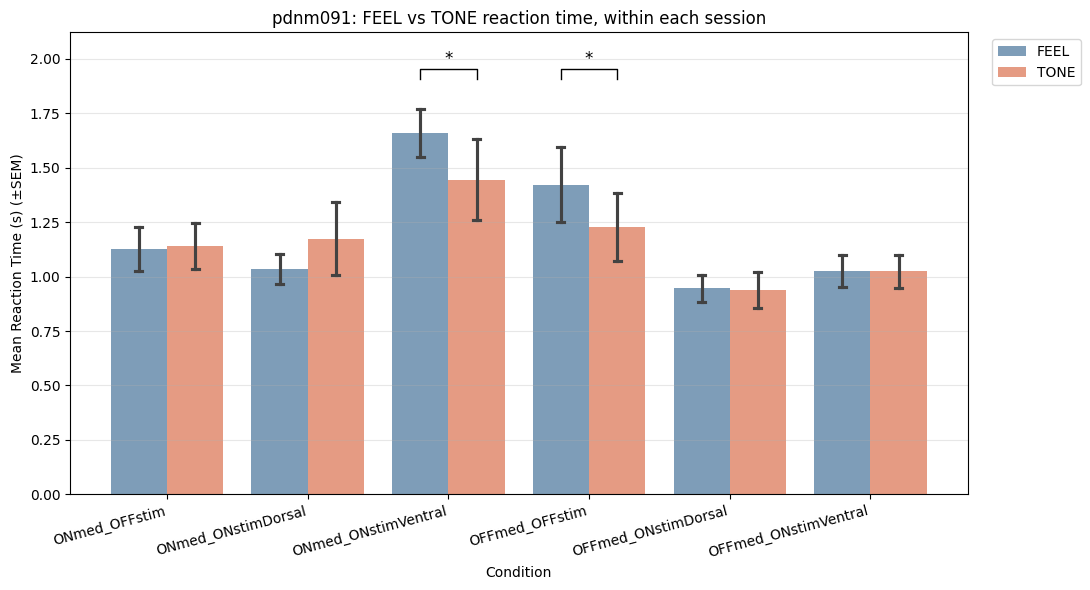

In [24]:
# Step 1: does FEEL vs TONE change RT within each session?
instr_results = []

for cond in condition_order_rt:
    cond_df = rt_df[rt_df['condition'] == cond]
    vals_feel = cond_df[cond_df['instruction'] == 'FEEL']['RT_Valence']
    vals_tone = cond_df[cond_df['instruction'] == 'TONE']['RT_Valence']

    stat, p = ranksums(vals_feel, vals_tone)

    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = ''

    instr_results.append({
        'condition': cond,
        'n_feel': len(vals_feel),
        'n_tone': len(vals_tone),
        'statistic': stat,
        'p_value': p,
        'stars': stars
    })

instr_results_df = pd.DataFrame(instr_results)
print(instr_results_df)

# Step 1 plot: condition on x-axis, FEEL/TONE as adjacent bars within each group
bar_width = 0.8 / len(cue_order)
cue_offsets_rt = {}
for i, c in enumerate(cue_order):
    cue_offsets_rt[c] = -0.4 + bar_width * (i + 0.5)

bar_stats = rt_df.groupby(['condition', 'instruction'])['RT_Valence'].agg(['mean', 'sem']).reset_index()
y_max = (bar_stats['mean'] + bar_stats['sem']).max()
bracket_height = y_max * 0.08

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=rt_df, x='condition', y='RT_Valence', hue='instruction',
    order=condition_order_rt, hue_order=cue_order, palette=cue_colors,
    errorbar='se', capsize=0.1, alpha=0.85, ax=ax
)

for i in range(len(instr_results_df)):
    row = instr_results_df.iloc[i]
    if row['stars'] == '':
        continue
    cond_x = condition_order_rt.index(row['condition'])
    x1 = cond_x + cue_offsets_rt['FEEL']
    x2 = cond_x + cue_offsets_rt['TONE']
    y = y_max + bracket_height
    ax.plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y], color='black', linewidth=1)
    ax.text((x1+x2)/2, y + bracket_height*0.35, row['stars'], ha='center', va='bottom', fontsize=12)

ax.set_ylim(0, y_max + bracket_height * 2.5)
ax.set_xlabel('Condition')
ax.set_ylabel('Mean Reaction Time (s) (±SEM)')
ax.set_title(f'{subj}: FEEL vs TONE reaction time, within each session')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()

               condition valence_bin  n_feel  n_tone  statistic   p_value  \
0          ONmed_OFFstim    negative       4      11   1.827815  0.067577   
1          ONmed_OFFstim     neutral      24      26  -0.893246  0.371725   
2          ONmed_OFFstim    positive      18      20   1.052470  0.292584   
3     ONmed_ONstimDorsal    negative      11      10  -0.985850  0.324207   
4     ONmed_ONstimDorsal     neutral      25      27  -0.430396  0.666907   
5     ONmed_ONstimDorsal    positive      18      20   0.263117  0.792460   
6    ONmed_ONstimVentral    negative      11      11  -0.426823  0.669509   
7    ONmed_ONstimVentral     neutral      25      27   2.371759  0.017704   
8    ONmed_ONstimVentral    positive      19      19   1.328361  0.184059   
9         OFFmed_OFFstim    negative      10      11  -0.633761  0.526237   
10        OFFmed_OFFstim     neutral      25      26   0.734847  0.462433   
11        OFFmed_OFFstim    positive      18      20   3.215879  0.001300   

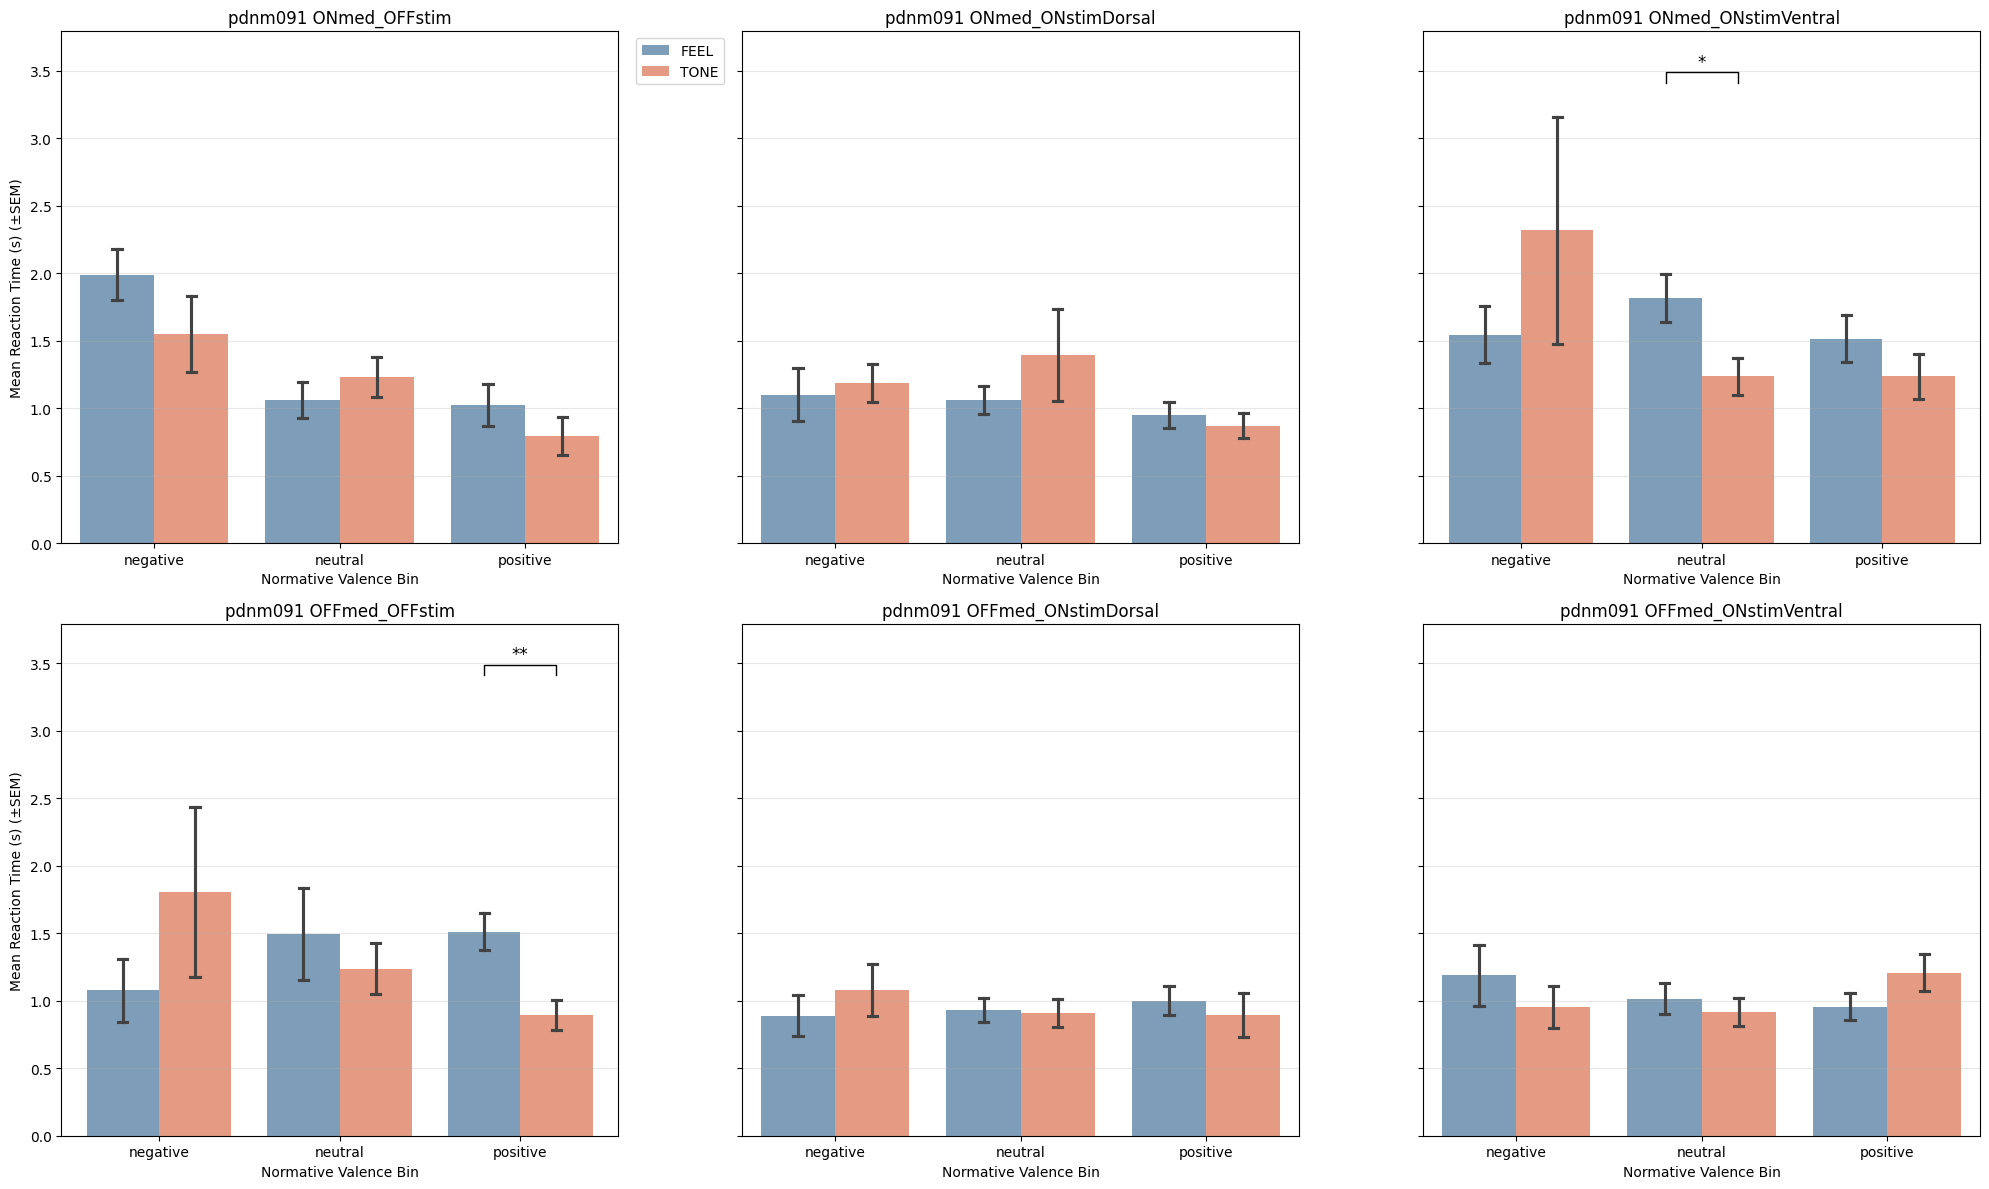

In [26]:
# Combine RT + valence bin + condition across all sessions
rt_valence_df = pd.concat([
    merged_df_ses01[['instruction', 'RT_Valence', 'normative_rating']].assign(condition=condition1),
    merged_df_ses02[['instruction', 'RT_Valence', 'normative_rating']].assign(condition=condition2),
    merged_df_ses03[['instruction', 'RT_Valence', 'normative_rating']].assign(condition=condition3),
    merged_df_ses04[['instruction', 'RT_Valence', 'normative_rating']].assign(condition=condition4),
    merged_df_ses05[['instruction', 'RT_Valence', 'normative_rating']].assign(condition=condition5),
    merged_df_ses06[['instruction', 'RT_Valence', 'normative_rating']].assign(condition=condition6),
], ignore_index=True)

def bin_valence(rating):
    if rating <= 3:
        return 'negative'
    elif rating <= 6:
        return 'neutral'
    else:
        return 'positive'

rt_valence_df['valence_bin'] = rt_valence_df['normative_rating'].apply(bin_valence)
bin_labels = ['negative', 'neutral', 'positive']

# Stats: FEEL vs TONE RT within each condition x valence bin
rt_instr_by_bin_results = []

for cond in condition_order_rt:
    for b in bin_labels:
        sub_df = rt_valence_df[(rt_valence_df['condition'] == cond) & (rt_valence_df['valence_bin'] == b)]
        vals_feel = sub_df[sub_df['instruction'] == 'FEEL']['RT_Valence']
        vals_tone = sub_df[sub_df['instruction'] == 'TONE']['RT_Valence']

        stat, p = ranksums(vals_feel, vals_tone)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        rt_instr_by_bin_results.append({
            'condition': cond,
            'valence_bin': b,
            'n_feel': len(vals_feel),
            'n_tone': len(vals_tone),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

rt_instr_by_bin_results_df = pd.DataFrame(rt_instr_by_bin_results)
print(rt_instr_by_bin_results_df)

# Plot: 6-panel grid, one per condition
bar_width = 0.8 / len(cue_order)
cue_offsets_rt = {}
for i, c in enumerate(cue_order):
    cue_offsets_rt[c] = -0.4 + bar_width * (i + 0.5)

bar_stats = rt_valence_df.groupby(['condition', 'valence_bin', 'instruction'])['RT_Valence'].agg(['mean', 'sem']).reset_index()
y_max = (bar_stats['mean'] + bar_stats['sem']).max()
bracket_height = y_max * 0.08

fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for idx, cond in enumerate(condition_order_rt):
    cond_df = rt_valence_df[rt_valence_df['condition'] == cond]

    sns.barplot(
        data=cond_df, x='valence_bin', y='RT_Valence', hue='instruction',
        order=bin_labels, hue_order=cue_order, palette=cue_colors,
        errorbar='se', capsize=0.1, alpha=0.85, ax=axes[idx]
    )

    cond_results = rt_instr_by_bin_results_df[rt_instr_by_bin_results_df['condition'] == cond]
    for i in range(len(cond_results)):
        row = cond_results.iloc[i]
        if row['stars'] == '':
            continue
        bin_x = bin_labels.index(row['valence_bin'])
        x1 = bin_x + cue_offsets_rt['FEEL']
        x2 = bin_x + cue_offsets_rt['TONE']
        y = y_max + bracket_height
        axes[idx].plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y], color='black', linewidth=1)
        axes[idx].text((x1+x2)/2, y + bracket_height*0.35, row['stars'], ha='center', va='bottom', fontsize=12)

    axes[idx].set_title(f'{subj} {cond}')
    axes[idx].set_xlabel('Normative Valence Bin')
    axes[idx].set_ylabel('Mean Reaction Time (s) (±SEM)' if idx % 3 == 0 else '')
    axes[idx].grid(True, axis='y', alpha=0.3)

axes[0].set_ylim(0, y_max + bracket_height * 2.5)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(cue_order)], labels[:len(cue_order)], loc='upper left', bbox_to_anchor=(1.02, 1))
for ax in axes[1:]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

In [18]:
rt_results = []

for instr in cue_order:
    instr_df = rt_df[rt_df['instruction'] == instr]

    for cond1, cond2 in combinations(condition_order_rt, 2):
        vals1 = instr_df[instr_df['condition'] == cond1]['RT_Valence']
        vals2 = instr_df[instr_df['condition'] == cond2]['RT_Valence']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        rt_results.append({
            'instruction': instr,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

rt_results_df = pd.DataFrame(rt_results)
print(rt_results_df)


# Just the comparisons involving ONmed_ONstimVentral, since that's the condition driving the claim
condition6_results = rt_results_df[
    (rt_results_df['condition_1'] == condition6) | (rt_results_df['condition_2'] == condition6)
]
print(condition6_results)

   instruction          condition_1           condition_2  n1  n2  statistic  \
0         FEEL        ONmed_OFFstim    ONmed_ONstimDorsal  46  54   0.580943   
1         FEEL        ONmed_OFFstim   ONmed_ONstimVentral  46  55  -3.361841   
2         FEEL        ONmed_OFFstim        OFFmed_OFFstim  46  53  -1.304929   
3         FEEL        ONmed_OFFstim   OFFmed_ONstimDorsal  46  55   1.261543   
4         FEEL        ONmed_OFFstim  OFFmed_ONstimVentral  46  54   0.788422   
5         FEEL   ONmed_ONstimDorsal   ONmed_ONstimVentral  54  55  -4.503030   
6         FEEL   ONmed_ONstimDorsal        OFFmed_OFFstim  54  53  -2.517244   
7         FEEL   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  54  55   0.539394   
8         FEEL   ONmed_ONstimDorsal  OFFmed_ONstimVentral  54  54   0.092167   
9         FEEL  ONmed_ONstimVentral        OFFmed_OFFstim  55  53   2.338367   
10        FEEL  ONmed_ONstimVentral   OFFmed_ONstimDorsal  55  55   5.144194   
11        FEEL  ONmed_ONstimVentral  OFF

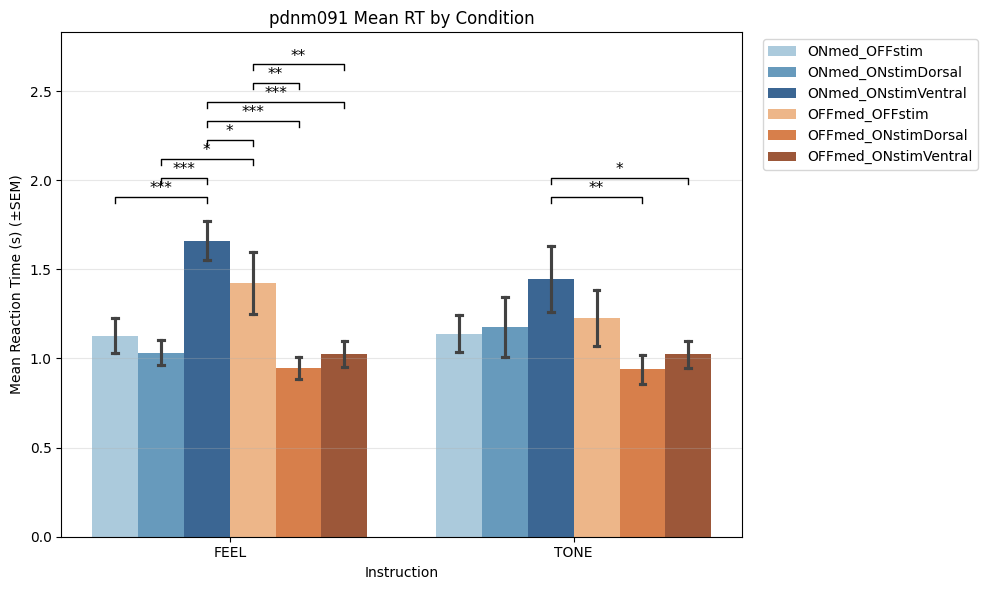

In [27]:
bar_width = 0.8 / len(condition_order_rt)
condition_offsets_rt = {}
for i, cond in enumerate(condition_order_rt):
    condition_offsets_rt[cond] = -0.4 + bar_width * (i + 0.5)

bar_stats = rt_df.groupby(['instruction', 'condition'])['RT_Valence'].agg(['mean', 'sem']).reset_index()
y_max = (bar_stats['mean'] + bar_stats['sem']).max()
bracket_height = y_max * 0.06

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=rt_df, x='instruction', y='RT_Valence', hue='condition',
    order=cue_order, hue_order=condition_order_rt, palette=condition_colors_rt,
    errorbar='se', capsize=0.1, alpha=0.85, ax=ax
)

# Use ALL significant pairs...
results_to_plot = rt_results_df
# ...OR uncomment this instead to only show comparisons against the outlier condition
# results_to_plot = rt_results_df[
#     (rt_results_df['condition_1'] == condition6) | (rt_results_df['condition_2'] == condition6)
# ]

instr_bracket_count = {instr: 0 for instr in cue_order}
for i in range(len(results_to_plot)):
    row = results_to_plot.iloc[i]
    if row['stars'] == '':
        continue

    instr_x = cue_order.index(row['instruction'])
    x1 = instr_x + condition_offsets_rt[row['condition_1']]
    x2 = instr_x + condition_offsets_rt[row['condition_2']]

    level = instr_bracket_count[row['instruction']]
    y = y_max + bracket_height * (level + 1)
    instr_bracket_count[row['instruction']] += 1

    ax.plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y],
            color='black', linewidth=1)
    ax.text((x1 + x2) / 2, y + bracket_height*0.35, row['stars'],
            ha='center', va='bottom', fontsize=11)

max_levels = max(instr_bracket_count.values()) if instr_bracket_count else 0
ax.set_ylim(0, y_max + bracket_height * (max_levels + 2))

ax.set_xlabel('Instruction')
ax.set_ylabel('Mean Reaction Time (s) (±SEM)')
ax.set_title(f'{subj} Mean RT by Condition')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

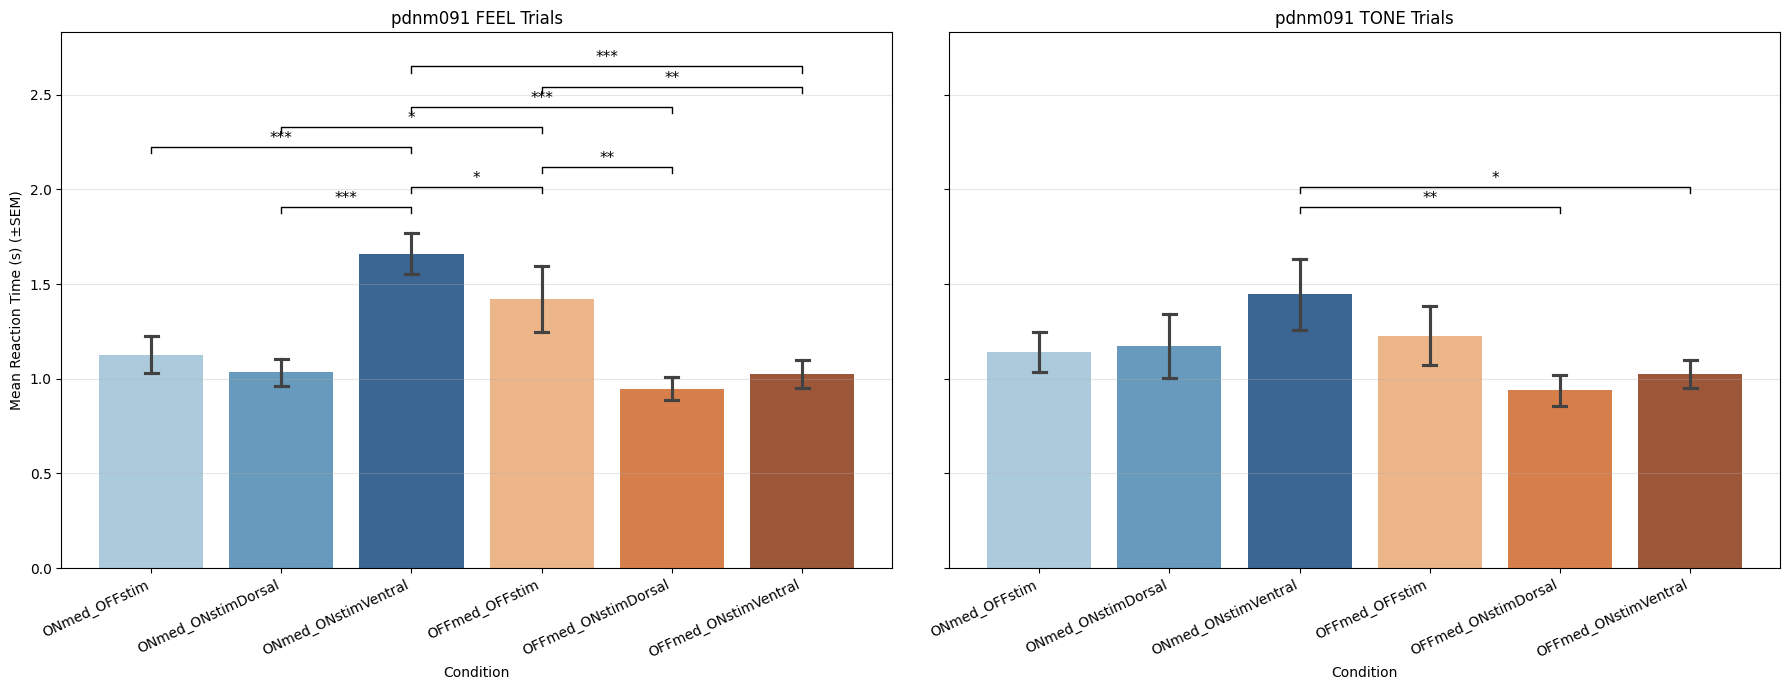

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

bar_stats = rt_df.groupby(['instruction', 'condition'])['RT_Valence'].agg(['mean', 'sem']).reset_index()
y_max = (bar_stats['mean'] + bar_stats['sem']).max()
bracket_height = y_max * 0.06

max_levels_used = 0

for ax_idx, instr in enumerate(cue_order):
    instr_df = rt_df[rt_df['instruction'] == instr]
    ax = axes[ax_idx]

    sns.barplot(
        data=instr_df, x='condition', y='RT_Valence', hue='condition',
        order=condition_order_rt, hue_order=condition_order_rt, palette=condition_colors_rt,
        errorbar='se', capsize=0.1, alpha=0.85, ax=ax, legend=False
    )

    # Only significant pairs for this instruction, sorted so short comparisons stack
    # low (close to bars) and long-spanning ones stack above them - avoids crossing
    sig = rt_results_df[(rt_results_df['instruction'] == instr) & (rt_results_df['stars'] != '')].copy()
    sig['x1'] = sig['condition_1'].apply(lambda c: condition_order_rt.index(c))
    sig['x2'] = sig['condition_2'].apply(lambda c: condition_order_rt.index(c))
    sig['span'] = (sig['x2'] - sig['x1']).abs()
    sig = sig.sort_values('span')

    for level, (_, row) in enumerate(sig.iterrows()):
        x1, x2 = row['x1'], row['x2']
        y = y_max + bracket_height * (level + 1)
        ax.plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y],
                color='black', linewidth=1)
        ax.text((x1 + x2) / 2, y + bracket_height*0.35, row['stars'], ha='center', va='bottom', fontsize=11)

    max_levels_used = max(max_levels_used, len(sig))
    ax.set_title(f'{subj} {instr} Trials')
    ax.set_xlabel('Condition')
    ax.set_ylabel('Mean Reaction Time (s) (±SEM)' if ax_idx == 0 else '')
    ax.grid(True, axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right')

axes[0].set_ylim(0, y_max + bracket_height * (max_levels_used + 2))

plt.tight_layout()
plt.show()

In [29]:
# **BINNING**

# Bin normative ratings into negative / neutral / positive
def bin_valence(rating):
    if rating <= 3:
        return 'negative'
    elif rating <= 6:
        return 'neutral'
    else:
        return 'positive'

merged_df_ses01['valence_bin'] = merged_df_ses01['normative_rating'].apply(bin_valence)
merged_df_ses02['valence_bin'] = merged_df_ses02['normative_rating'].apply(bin_valence)
merged_df_ses03['valence_bin'] = merged_df_ses03['normative_rating'].apply(bin_valence)
merged_df_ses04['valence_bin'] = merged_df_ses04['normative_rating'].apply(bin_valence)
merged_df_ses05['valence_bin'] = merged_df_ses05['normative_rating'].apply(bin_valence)
merged_df_ses06['valence_bin'] = merged_df_ses06['normative_rating'].apply(bin_valence)

print(merged_df_ses01['valence_bin'].value_counts())
print(merged_df_ses02['valence_bin'].value_counts())
print(merged_df_ses03['valence_bin'].value_counts())
print(merged_df_ses04['valence_bin'].value_counts())
print(merged_df_ses05['valence_bin'].value_counts())
print(merged_df_ses06['valence_bin'].value_counts())

valence_bin
neutral     52
positive    38
negative    21
Name: count, dtype: int64
valence_bin
neutral     54
positive    37
negative    21
Name: count, dtype: int64
valence_bin
neutral     54
positive    38
negative    20
Name: count, dtype: int64
valence_bin
neutral     50
positive    38
negative    15
Name: count, dtype: int64
valence_bin
neutral     51
positive    38
negative    21
Name: count, dtype: int64
valence_bin
neutral     52
positive    38
negative    22
Name: count, dtype: int64


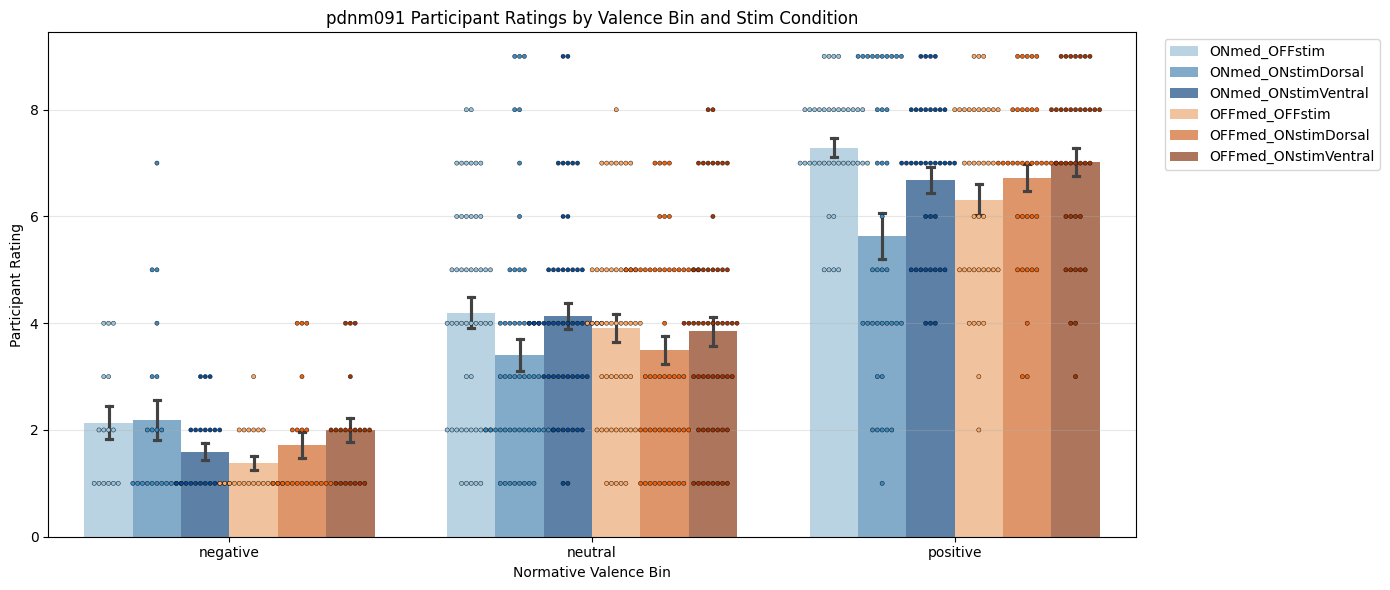

In [32]:
# Combine all sessions into one long dataframe for plotting
plot_df = pd.concat([
    merged_df_ses01.assign(condition=condition1),
    merged_df_ses02.assign(condition=condition2),
    merged_df_ses03.assign(condition=condition3),
    merged_df_ses04.assign(condition=condition4),
    merged_df_ses05.assign(condition=condition5),
    merged_df_ses06.assign(condition=condition6),
], ignore_index=True)

plot_df['participant_rating'] = plot_df['participant_rating'].apply(
    lambda v: v.item() if isinstance(v, np.ndarray) else v
)
plot_df = plot_df.dropna(subset=['participant_rating', 'valence_bin'])

bin_labels = ['negative', 'neutral', 'positive']
condition_order = [condition4, condition1, condition6, condition5, condition2, condition3]
condition_colors = ['#94c4df', '#3b8bc2', '#084a91', '#fda762', '#ec620f', '#9e3303']


fig, ax = plt.subplots(figsize=(14, 6))

# Bars: mean +- SEM
sns.barplot(
    data=plot_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=ax
)

# Swarm: individual points, dodged to match bar positions
sns.swarmplot(
    data=plot_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=ax
)

# Remove duplicate legend entries (bar + swarm both add one)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)],
          loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_xlabel('Normative Valence Bin')
ax.set_ylabel('Participant Rating')
ax.set_title(f'{subj} Participant Ratings by Valence Bin and Stim Condition')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

               condition valence_bin  n_feel  n_tone  statistic   p_value  \
0          ONmed_OFFstim    negative       4      11  -0.652791  0.513891   
1          ONmed_OFFstim     neutral      24      26   1.310741  0.189945   
2          ONmed_OFFstim    positive      18      20   1.198646  0.230666   
3     ONmed_ONstimDorsal    negative      11      10  -1.021059  0.307226   
4     ONmed_ONstimDorsal     neutral      25      27   0.283878  0.776503   
5     ONmed_ONstimDorsal    positive      18      20   3.932143  0.000084   
6    ONmed_ONstimVentral    negative      11      11  -2.987758  0.002810   
7    ONmed_ONstimVentral     neutral      25      27  -0.018315  0.985388   
8    ONmed_ONstimVentral    positive      19      19   2.218801  0.026500   
9         OFFmed_OFFstim    negative      10      11  -1.760447  0.078332   
10        OFFmed_OFFstim     neutral      25      26   0.876164  0.380941   
11        OFFmed_OFFstim    positive      18      20   1.520234  0.128452   

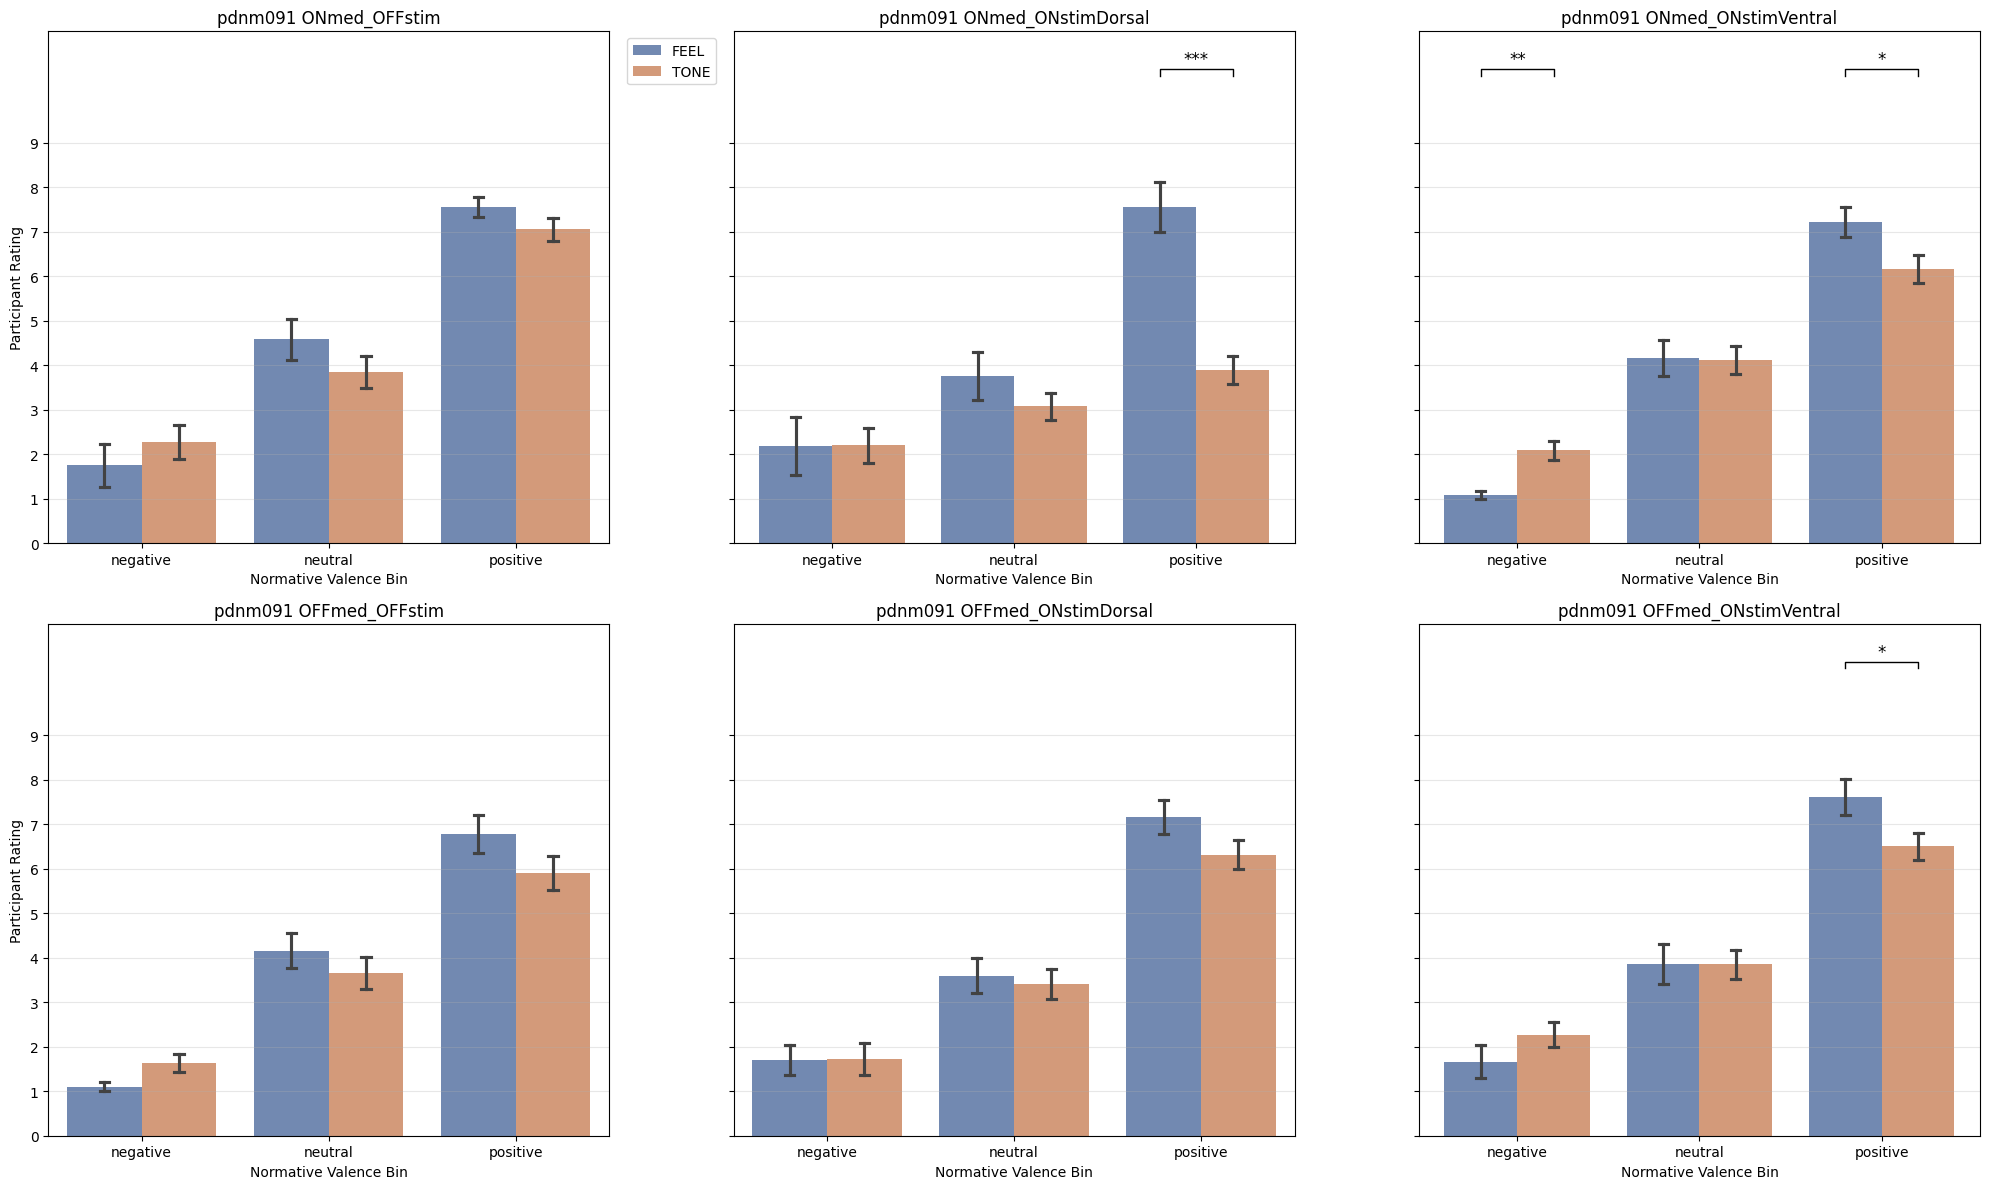

In [50]:
# Stats: FEEL vs TONE participant rating, within each condition x valence bin
rating_instr_by_bin_results = []

for cond in condition_order_rt:
    for b in bin_labels:
        sub_df = plot_df[(plot_df['condition'] == cond) & (plot_df['valence_bin'] == b)]
        vals_feel = sub_df[sub_df['instruction'] == 'FEEL']['participant_rating']
        vals_tone = sub_df[sub_df['instruction'] == 'TONE']['participant_rating']

        stat, p = ranksums(vals_feel, vals_tone)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        rating_instr_by_bin_results.append({
            'condition': cond,
            'valence_bin': b,
            'n_feel': len(vals_feel),
            'n_tone': len(vals_tone),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

rating_instr_by_bin_results_df = pd.DataFrame(rating_instr_by_bin_results)
print(rating_instr_by_bin_results_df)

# Plot: 2x3 grid, one panel per condition, valence bin on x-axis, FEEL/TONE as adjacent bars
bar_width = 0.8 / len(cue_order)
cue_offsets_rating = {}
for i, c in enumerate(cue_order):
    cue_offsets_rating[c] = -0.4 + bar_width * (i + 0.5)

y_max = 10
bracket_height = y_max * 0.05

fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for idx, cond in enumerate(condition_order_rt):
    cond_df = plot_df[plot_df['condition'] == cond]

    sns.barplot(
        data=cond_df, x='valence_bin', y='participant_rating', hue='instruction',
        order=bin_labels, hue_order=cue_order, palette=cue_colors,
        errorbar='se', capsize=0.1, alpha=0.85, ax=axes[idx]
    )

    cond_results = rating_instr_by_bin_results_df[rating_instr_by_bin_results_df['condition'] == cond]
    for i in range(len(cond_results)):
        row = cond_results.iloc[i]
        if row['stars'] == '':
            continue
        bin_x = bin_labels.index(row['valence_bin'])
        x1 = bin_x + cue_offsets_rating['FEEL']
        x2 = bin_x + cue_offsets_rating['TONE']
        y = y_max + bracket_height
        axes[idx].plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y], color='black', linewidth=1)
        axes[idx].text((x1+x2)/2, y + bracket_height*0.35, row['stars'], ha='center', va='bottom', fontsize=12)

    axes[idx].set_title(f'{subj} {cond}')
    axes[idx].set_xlabel('Normative Valence Bin')
    axes[idx].set_ylabel('Participant Rating' if idx % 3 == 0 else '')
    axes[idx].grid(True, axis='y', alpha=0.3)

axes[0].set_ylim(0, y_max + bracket_height * 3)
axes[0].set_yticks(np.arange(0, 10, 1))

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(cue_order)], labels[:len(cue_order)], loc='upper left', bbox_to_anchor=(1.02, 1))
for ax in axes[1:]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

In [33]:
results = []

for b in bin_labels:
    bin_df = plot_df[plot_df['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        results.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

results_df = pd.DataFrame(results)
print(results_df)

   valence_bin          condition_1           condition_2  n1  n2  statistic  \
0     negative        ONmed_OFFstim    ONmed_ONstimDorsal  15  21   0.385049   
1     negative        ONmed_OFFstim   ONmed_ONstimVentral  15  22   1.237376   
2     negative        ONmed_OFFstim        OFFmed_OFFstim  15  21   1.812938   
3     negative        ONmed_OFFstim   OFFmed_ONstimDorsal  15  21   1.123059   
4     negative        ONmed_OFFstim  OFFmed_ONstimVentral  15  20   0.183333   
5     negative   ONmed_ONstimDorsal   ONmed_ONstimVentral  21  22   0.631708   
6     negative   ONmed_ONstimDorsal        OFFmed_OFFstim  21  21   1.245209   
7     negative   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  21  21   0.716939   
8     negative   ONmed_ONstimDorsal  OFFmed_ONstimVentral  21  20  -0.365148   
9     negative  ONmed_ONstimVentral        OFFmed_OFFstim  22  21   0.813932   
10    negative  ONmed_ONstimVentral   OFFmed_ONstimDorsal  22  21   0.109334   
11    negative  ONmed_ONstimVentral  OFF

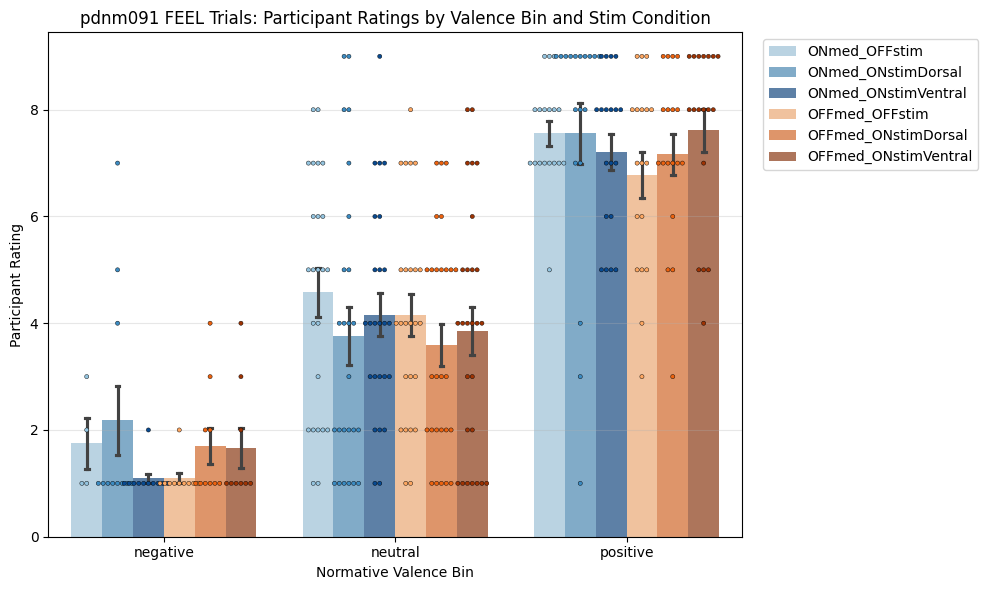

In [35]:
# Filter to only FEEL trials
feel_df = plot_df[plot_df['instruction'] == 'FEEL']

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=feel_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=ax
)

sns.swarmplot(
    data=feel_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)],
          loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_xlabel('Normative Valence Bin')
ax.set_ylabel('Participant Rating')
ax.set_title(f'{subj} FEEL Trials: Participant Ratings by Valence Bin and Stim Condition')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
feel_results = []

for b in bin_labels:
    bin_df = feel_df[feel_df['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        feel_results.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

feel_results_df = pd.DataFrame(feel_results)
print(feel_results_df)

   valence_bin          condition_1           condition_2  n1  n2  statistic  \
0     negative        ONmed_OFFstim    ONmed_ONstimDorsal   4  11   0.261116   
1     negative        ONmed_OFFstim   ONmed_ONstimVentral   4  11   1.240303   
2     negative        ONmed_OFFstim        OFFmed_OFFstim   4  10   1.202082   
3     negative        ONmed_OFFstim   OFFmed_ONstimDorsal   4  10   0.212132   
4     negative        ONmed_OFFstim  OFFmed_ONstimVentral   4   9   0.308607   
5     negative   ONmed_ONstimDorsal   ONmed_ONstimVentral  11  11   0.820813   
6     negative   ONmed_ONstimDorsal        OFFmed_OFFstim  11  10   0.774597   
7     negative   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  11  10  -0.105627   
8     negative   ONmed_ONstimDorsal  OFFmed_ONstimVentral  11   9   0.075974   
9     negative  ONmed_ONstimVentral        OFFmed_OFFstim  11  10  -0.035209   
10    negative  ONmed_ONstimVentral   OFFmed_ONstimDorsal  11  10  -1.267522   
11    negative  ONmed_ONstimVentral  OFF

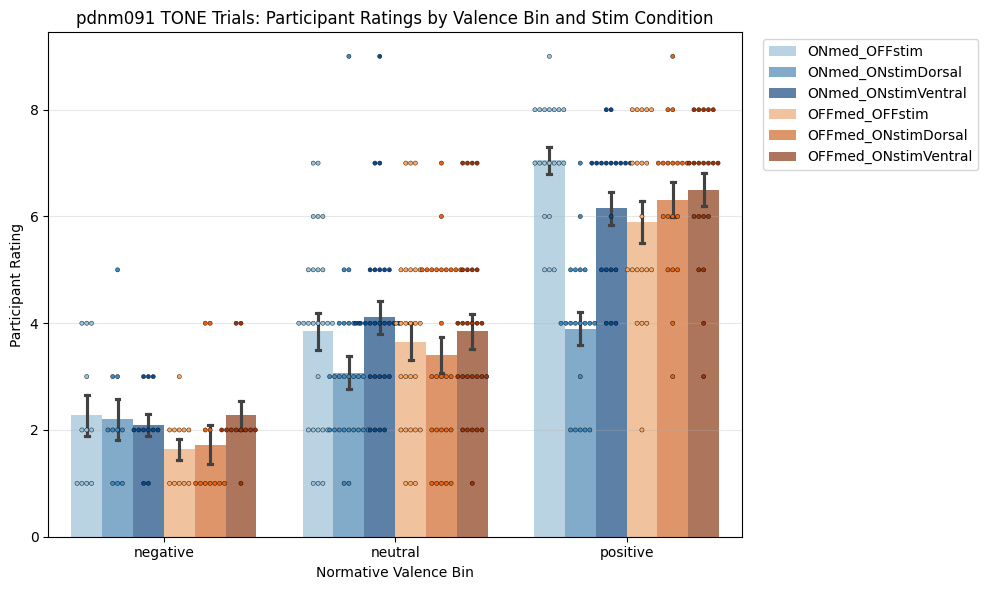

In [37]:
# Filter to only TONE trials
tone_df = plot_df[plot_df['instruction'] == 'TONE']

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=tone_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=ax
)

sns.swarmplot(
    data=tone_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)],
          loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_xlabel('Normative Valence Bin')
ax.set_ylabel('Participant Rating')
ax.set_title(f'{subj} TONE Trials: Participant Ratings by Valence Bin and Stim Condition')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
tone_results = []

for b in bin_labels:
    bin_df = tone_df[tone_df['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        tone_results.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

tone_results_df = pd.DataFrame(tone_results)
print(tone_results_df)

   valence_bin          condition_1           condition_2  n1  n2  statistic  \
0     negative        ONmed_OFFstim    ONmed_ONstimDorsal  11  10   0.070418   
1     negative        ONmed_OFFstim   ONmed_ONstimVentral  11  11   0.065665   
2     negative        ONmed_OFFstim        OFFmed_OFFstim  11  11   1.017808   
3     negative        ONmed_OFFstim   OFFmed_ONstimDorsal  11  11   1.083473   
4     negative        ONmed_OFFstim  OFFmed_ONstimVentral  11  11  -0.295493   
5     negative   ONmed_ONstimDorsal   ONmed_ONstimVentral  10  11  -0.140836   
6     negative   ONmed_ONstimDorsal        OFFmed_OFFstim  10  11   1.021059   
7     negative   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  10  11   1.161895   
8     negative   ONmed_ONstimDorsal  OFFmed_ONstimVentral  10  11  -0.316880   
9     negative  ONmed_ONstimVentral        OFFmed_OFFstim  11  11   1.378965   
10    negative  ONmed_ONstimVentral   OFFmed_ONstimDorsal  11  11   1.411798   
11    negative  ONmed_ONstimVentral  OFF

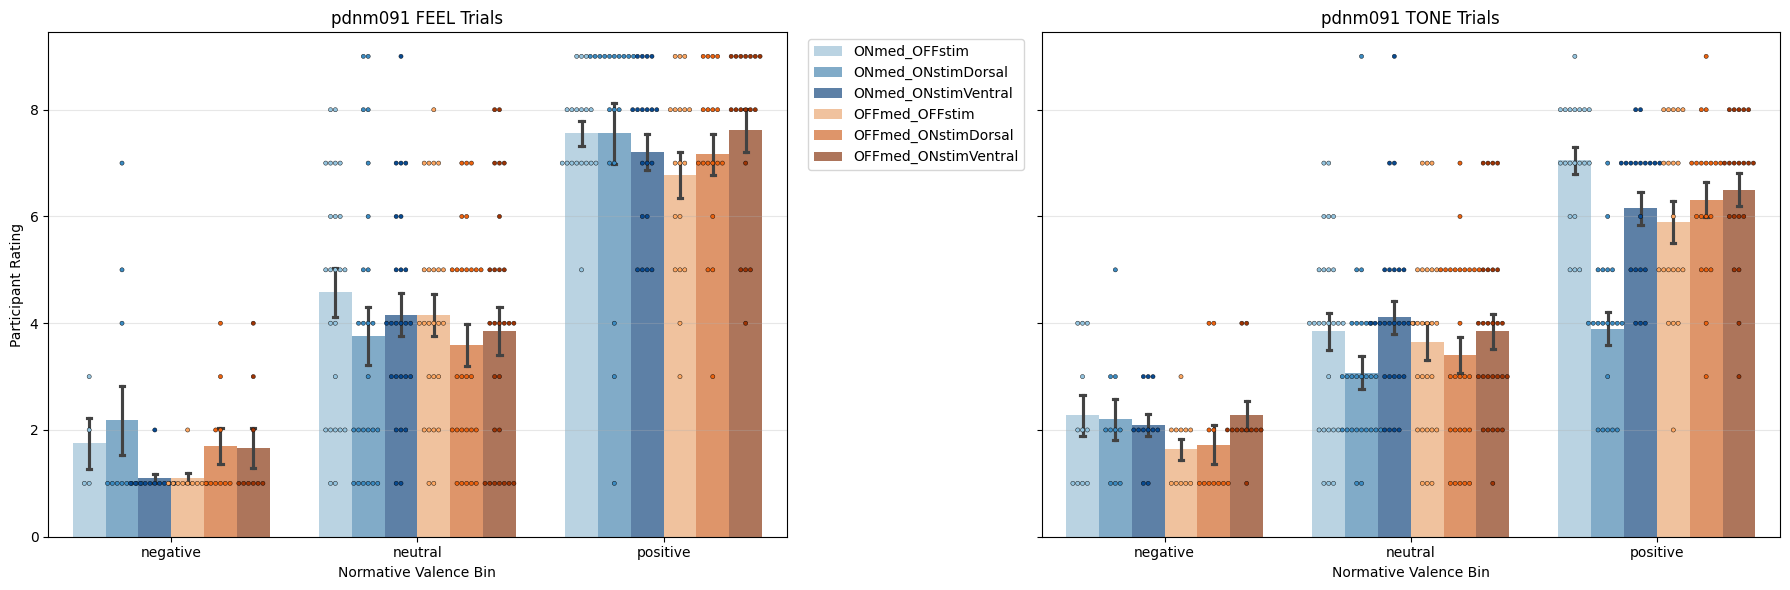

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.barplot(
    data=feel_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[0]
)
sns.swarmplot(
    data=feel_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[0]
)
axes[0].set_title(f'{subj} FEEL Trials')
axes[0].set_xlabel('Normative Valence Bin')
axes[0].set_ylabel('Participant Rating')
axes[0].grid(True, axis='y', alpha=0.3)

sns.barplot(
    data=tone_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[1]
)
sns.swarmplot(
    data=tone_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[1]
)
axes[1].set_title(f'{subj} TONE Trials')
axes[1].set_xlabel('Normative Valence Bin')
axes[1].set_ylabel('')
axes[1].grid(True, axis='y', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(condition_order)], labels[:len(condition_order)],
               loc='upper left', bbox_to_anchor=(1.02, 1))
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

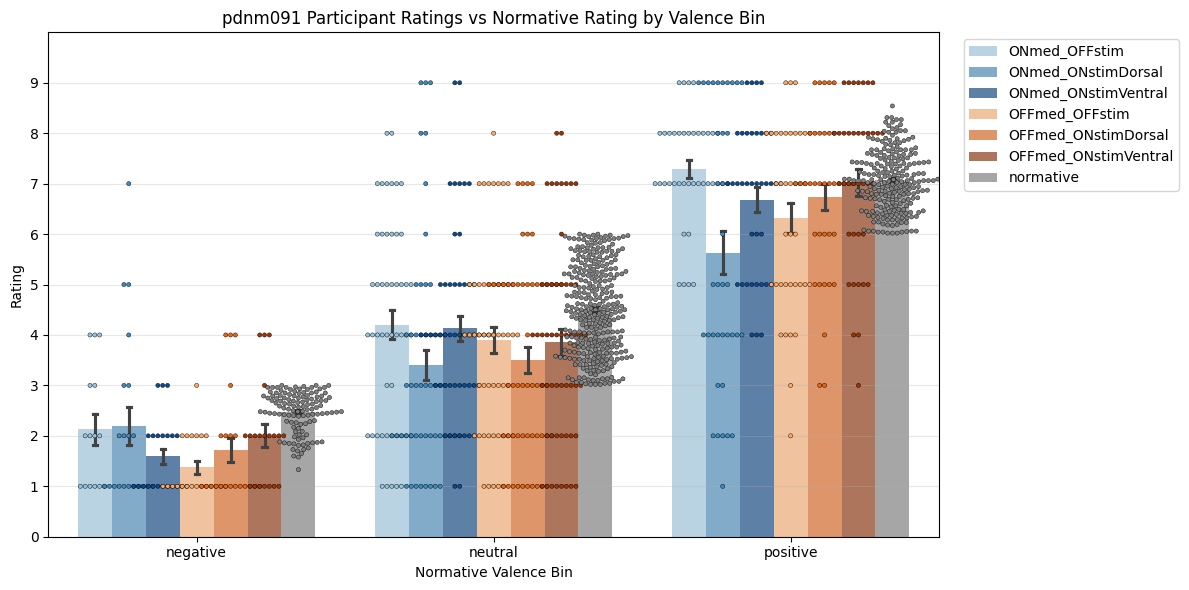

In [40]:
# Build a "normative" pseudo-condition using the normative_rating column,
# so it can sit alongside the 3 stim conditions as a 4th bar

normative_df = plot_df[['valence_bin', 'normative_rating']].copy()
normative_df = normative_df.rename(columns={'normative_rating': 'participant_rating'})
normative_df['condition'] = 'normative'

plot_df_with_norm = pd.concat([
    plot_df[['valence_bin', 'condition', 'participant_rating']],
    normative_df
], ignore_index=True)

condition_order_with_norm = condition_order + ['normative']
condition_colors_with_norm = condition_colors + ['grey']

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_ylim(0, 10)
ax.set_yticks(np.arange(0, 10, 1))

sns.barplot(
    data=plot_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    errorbar='se', capsize=0.1, alpha=0.7, ax=ax
)

sns.swarmplot(
    data=plot_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order_with_norm)], labels[:len(condition_order_with_norm)],
          loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_xlabel('Normative Valence Bin')
ax.set_ylabel('Rating')
ax.set_title(f'{subj} Participant Ratings vs Normative Rating by Valence Bin')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
results_with_norm = []

for b in bin_labels:
    bin_df = plot_df_with_norm[plot_df_with_norm['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order_with_norm, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        results_with_norm.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

results_with_norm_df = pd.DataFrame(results_with_norm)
print(results_with_norm_df)

   valence_bin           condition_1           condition_2  n1   n2  \
0     negative         ONmed_OFFstim    ONmed_ONstimDorsal  15   21   
1     negative         ONmed_OFFstim   ONmed_ONstimVentral  15   22   
2     negative         ONmed_OFFstim        OFFmed_OFFstim  15   21   
3     negative         ONmed_OFFstim   OFFmed_ONstimDorsal  15   21   
4     negative         ONmed_OFFstim  OFFmed_ONstimVentral  15   20   
..         ...                   ...                   ...  ..  ...   
58    positive        OFFmed_OFFstim  OFFmed_ONstimVentral  38   38   
59    positive        OFFmed_OFFstim             normative  38  227   
60    positive   OFFmed_ONstimDorsal  OFFmed_ONstimVentral  37   38   
61    positive   OFFmed_ONstimDorsal             normative  37  227   
62    positive  OFFmed_ONstimVentral             normative  38  227   

    statistic   p_value stars  
0    0.385049  0.700201        
1    1.237376  0.215947        
2    1.812938  0.069841        
3    1.123059  0.26

In [42]:
# ---- FEEL: build normative-included dataframe ----
feel_normative_df = feel_df[['valence_bin', 'normative_rating']].copy()
feel_normative_df = feel_normative_df.rename(columns={'normative_rating': 'participant_rating'})
feel_normative_df['condition'] = 'normative'

feel_df_with_norm = pd.concat([
    feel_df[['valence_bin', 'condition', 'participant_rating']],
    feel_normative_df
], ignore_index=True)

# ---- TONE: build normative-included dataframe ----
tone_normative_df = tone_df[['valence_bin', 'normative_rating']].copy()
tone_normative_df = tone_normative_df.rename(columns={'normative_rating': 'participant_rating'})
tone_normative_df['condition'] = 'normative'

tone_df_with_norm = pd.concat([
    tone_df[['valence_bin', 'condition', 'participant_rating']],
    tone_normative_df
], ignore_index=True)

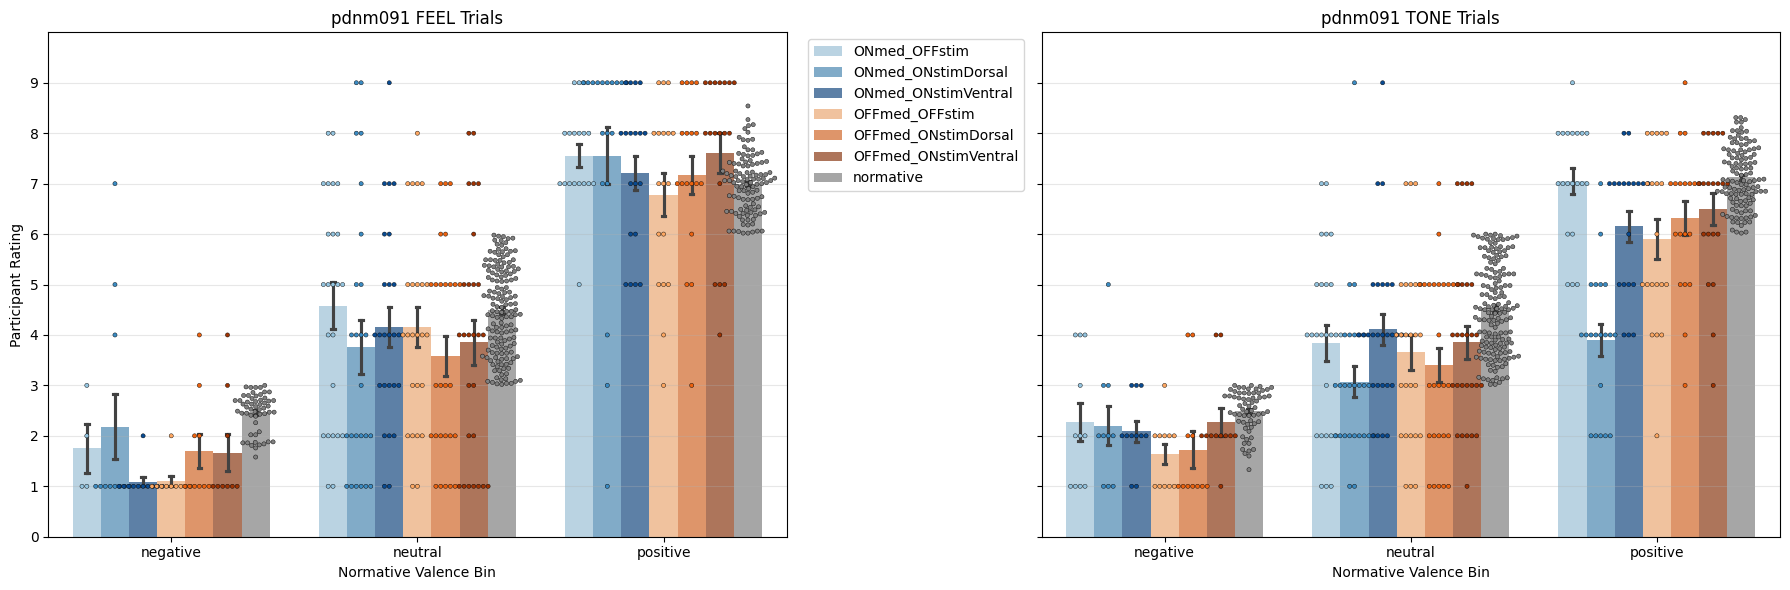

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.barplot(
    data=feel_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[0]
)
sns.swarmplot(
    data=feel_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[0]
)
axes[0].set_title(f'{subj} FEEL Trials')
axes[0].set_xlabel('Normative Valence Bin')
axes[0].set_ylabel('Participant Rating')
axes[0].grid(True, axis='y', alpha=0.3)

sns.barplot(
    data=tone_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[1]
)
sns.swarmplot(
    data=tone_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[1]
)
axes[1].set_title(f'{subj} TONE Trials')
axes[1].set_xlabel('Normative Valence Bin')
axes[1].set_ylabel('')
axes[1].grid(True, axis='y', alpha=0.3)

axes[0].set_ylim(0, 10)
axes[0].set_yticks(np.arange(0, 10, 1))

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(condition_order_with_norm)], labels[:len(condition_order_with_norm)],
               loc='upper left', bbox_to_anchor=(1.02, 1))
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

In [44]:
# ---- FEEL: Wilcoxon tests including normative ----
feel_results_with_norm = []

for b in bin_labels:
    bin_df = feel_df_with_norm[feel_df_with_norm['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order_with_norm, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        feel_results_with_norm.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

feel_results_with_norm_df = pd.DataFrame(feel_results_with_norm)
feel_results_with_norm_df

,valence_bin,condition_1,condition_2,n1,n2,statistic,p_value,stars
0,negative,ONmed_OFFstim,ONmed_ONstimDorsal,4,11,0.261116,0.794003,
1,negative,ONmed_OFFstim,ONmed_ONstimVentral,4,11,1.240303,0.214863,
2,negative,ONmed_OFFstim,OFFmed_OFFstim,4,10,1.202082,0.229332,
3,negative,ONmed_OFFstim,OFFmed_ONstimDorsal,4,10,0.212132,0.832004,
4,negative,ONmed_OFFstim,OFFmed_ONstimVentral,4,9,0.308607,0.757621,
...,...,...,...,...,...,...,...,...
58,positive,OFFmed_OFFstim,OFFmed_ONstimVentral,18,18,-1.550291,0.121072,
59,positive,OFFmed_OFFstim,normative,18,109,0.086406,0.931143,
60,positive,OFFmed_ONstimDorsal,OFFmed_ONstimVentral,18,18,-1.138990,0.254707,
61,positive,OFFmed_ONstimDorsal,normative,18,109,1.175128,0.239944,


In [45]:
# ---- TONE: Wilcoxon tests including normative ----
tone_results_with_norm = []

for b in bin_labels:
    bin_df = tone_df_with_norm[tone_df_with_norm['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order_with_norm, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        tone_results_with_norm.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

tone_results_with_norm_df = pd.DataFrame(tone_results_with_norm)
tone_results_with_norm_df

,valence_bin,condition_1,condition_2,n1,n2,statistic,p_value,stars
0,negative,ONmed_OFFstim,ONmed_ONstimDorsal,11,10,0.070418,0.943861,
1,negative,ONmed_OFFstim,ONmed_ONstimVentral,11,11,0.065665,0.947645,
2,negative,ONmed_OFFstim,OFFmed_OFFstim,11,11,1.017808,0.308769,
3,negative,ONmed_OFFstim,OFFmed_ONstimDorsal,11,11,1.083473,0.278599,
4,negative,ONmed_OFFstim,OFFmed_ONstimVentral,11,11,-0.295493,0.767618,
...,...,...,...,...,...,...,...,...
58,positive,OFFmed_OFFstim,OFFmed_ONstimVentral,20,20,-1.027903,0.303995,
59,positive,OFFmed_OFFstim,normative,20,118,-2.564443,0.010334,*
60,positive,OFFmed_ONstimDorsal,OFFmed_ONstimVentral,19,20,-0.547903,0.583759,
61,positive,OFFmed_ONstimDorsal,normative,19,118,-2.547162,0.010860,*


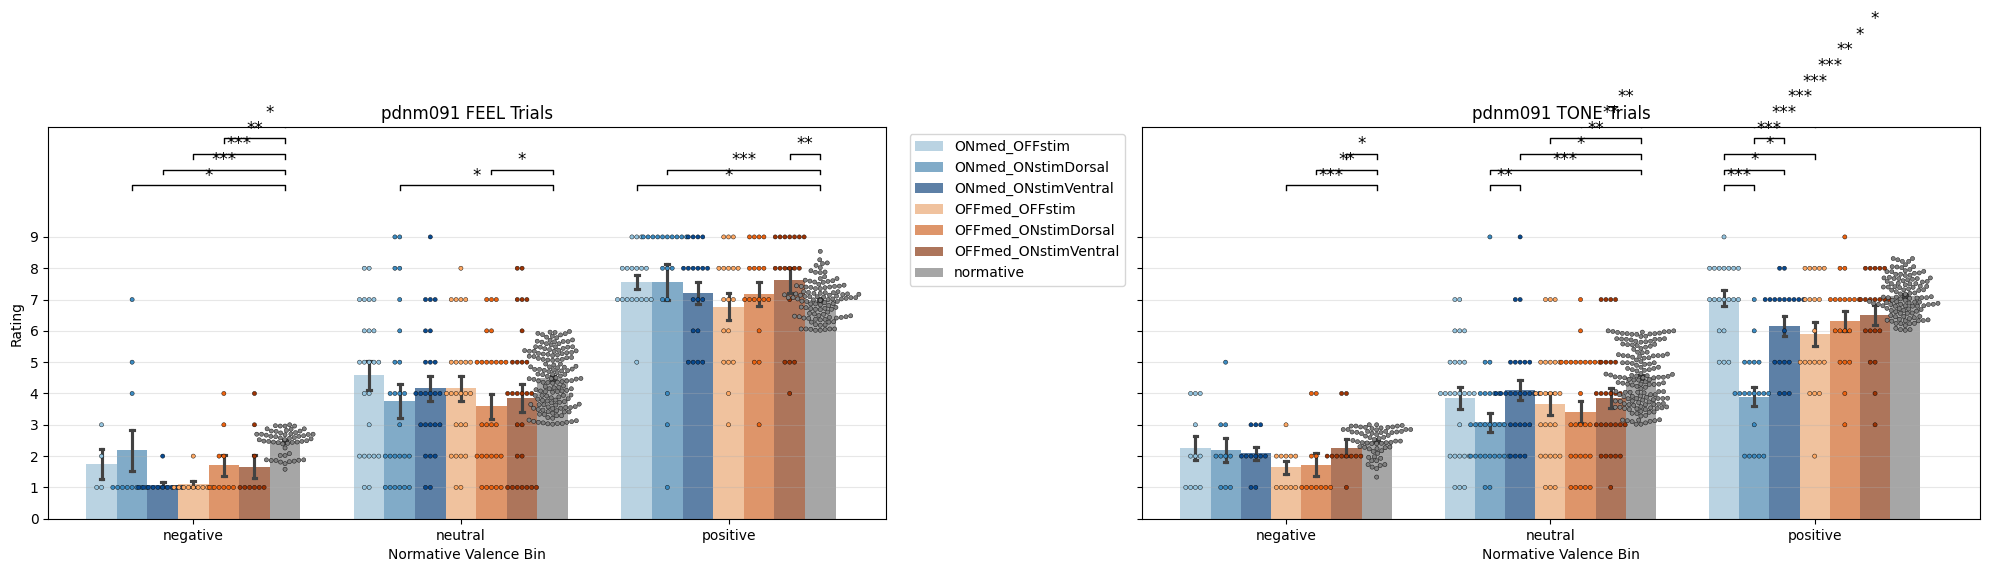

In [51]:
bar_width = 0.8 / len(condition_order_with_norm)
condition_offsets = {}
for i, cond in enumerate(condition_order_with_norm):
    condition_offsets[cond] = -0.4 + bar_width * (i + 0.5)

y_max = 10
bracket_height = y_max * 0.05

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# ---- FEEL ----
sns.barplot(
    data=feel_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[0]
)
sns.swarmplot(
    data=feel_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[0]
)

bin_bracket_count = {b: 0 for b in bin_labels}
for i in range(len(feel_results_with_norm_df)):
    row = feel_results_with_norm_df.iloc[i]
    if row['stars'] == '':
        continue

    bin_x = bin_labels.index(row['valence_bin'])
    x1 = bin_x + condition_offsets[row['condition_1']]
    x2 = bin_x + condition_offsets[row['condition_2']]

    level = bin_bracket_count[row['valence_bin']]
    y = y_max + bracket_height * (level + 1)
    bin_bracket_count[row['valence_bin']] += 1

    axes[0].plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y],
                 color='black', linewidth=1)
    axes[0].text((x1 + x2) / 2, y + bracket_height*0.35, row['stars'],
                 ha='center', va='bottom', fontsize=12)

axes[0].set_title(f'{subj} FEEL Trials')
axes[0].set_xlabel('Normative Valence Bin')
axes[0].set_ylabel('Rating')
axes[0].grid(True, axis='y', alpha=0.3)

# ---- TONE ----
sns.barplot(
    data=tone_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[1]
)
sns.swarmplot(
    data=tone_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[1]
)

bin_bracket_count = {b: 0 for b in bin_labels}
for i in range(len(tone_results_with_norm_df)):
    row = tone_results_with_norm_df.iloc[i]
    if row['stars'] == '':
        continue

    bin_x = bin_labels.index(row['valence_bin'])
    x1 = bin_x + condition_offsets[row['condition_1']]
    x2 = bin_x + condition_offsets[row['condition_2']]

    level = bin_bracket_count[row['valence_bin']]
    y = y_max + bracket_height * (level + 1)
    bin_bracket_count[row['valence_bin']] += 1

    axes[1].plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y],
                 color='black', linewidth=1)
    axes[1].text((x1 + x2) / 2, y + bracket_height*0.35, row['stars'],
                 ha='center', va='bottom', fontsize=12)

axes[1].set_title(f'{subj} TONE Trials')
axes[1].set_xlabel('Normative Valence Bin')
axes[1].set_ylabel('')
axes[1].grid(True, axis='y', alpha=0.3)

axes[0].set_ylim(0, 12.5)
axes[0].set_yticks(np.arange(0, 10, 1))

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(condition_order_with_norm)], labels[:len(condition_order_with_norm)],
               loc='upper left', bbox_to_anchor=(1.02, 1))
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

               condition instruction valence_bin   n  mean_diff  statistic  \
2          ONmed_OFFstim        FEEL    positive  18   0.561111       32.0   
10    ONmed_ONstimDorsal        TONE     neutral  27  -1.514074       25.0   
11    ONmed_ONstimDorsal        TONE    positive  20  -3.270500        1.0   
12   ONmed_ONstimVentral        FEEL    negative  11  -1.475455        0.0   
16   ONmed_ONstimVentral        TONE     neutral  27  -0.421852      106.0   
17   ONmed_ONstimVentral        TONE    positive  19  -0.978421       20.0   
18        OFFmed_OFFstim        FEEL    negative  10  -1.350000        0.0   
21        OFFmed_OFFstim        TONE    negative  11  -0.668182        7.0   
22        OFFmed_OFFstim        TONE     neutral  26  -0.823077       60.0   
23        OFFmed_OFFstim        TONE    positive  20  -1.258500       31.0   
24   OFFmed_ONstimDorsal        FEEL    negative  10  -0.747000        8.0   
25   OFFmed_ONstimDorsal        FEEL     neutral  27  -0.910741 

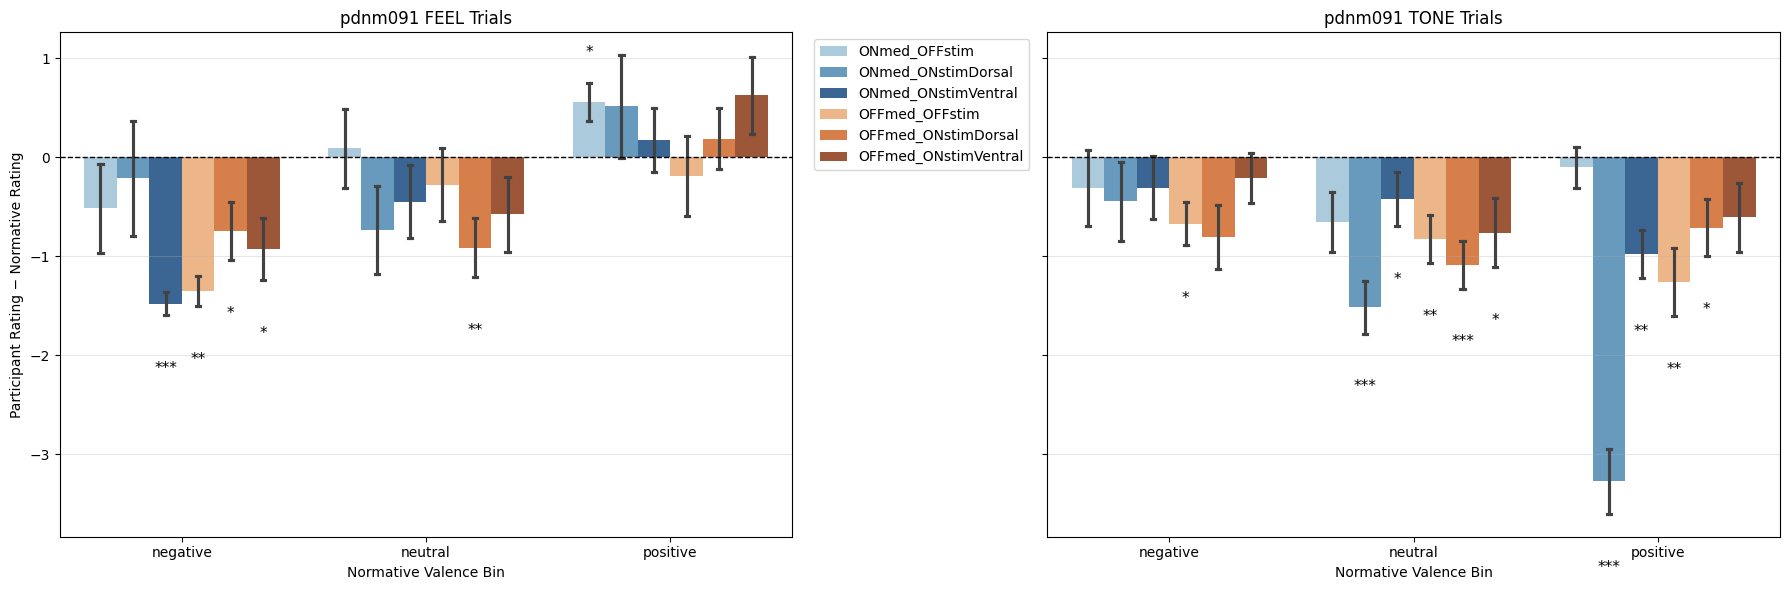

In [56]:
from scipy.stats import wilcoxon

# One-sample test: does diff_rating (participant - normative) differ from 0,
# within each condition x instruction x valence bin? Correctly paired, unlike
# the ranksums comparison against a separate "normative" pseudo-condition.
diff_sig_results = []

for cond in condition_order_rt:
    for instr in cue_order:
        for b in bin_labels:
            sub_df = plot_df[
                (plot_df['condition'] == cond) &
                (plot_df['instruction'] == instr) &
                (plot_df['valence_bin'] == b)
            ]
            diffs = sub_df['diff_rating'].dropna()

            if len(diffs) < 5 or (diffs == 0).all():
                stat, p = np.nan, np.nan
            else:
                stat, p = wilcoxon(diffs)

            if np.isnan(p):
                stars = ''
            elif p < 0.001:
                stars = '***'
            elif p < 0.01:
                stars = '**'
            elif p < 0.05:
                stars = '*'
            else:
                stars = ''

            diff_sig_results.append({
                'condition': cond,
                'instruction': instr,
                'valence_bin': b,
                'n': len(diffs),
                'mean_diff': diffs.mean(),
                'statistic': stat,
                'p_value': p,
                'stars': stars
            })

diff_sig_results_df = pd.DataFrame(diff_sig_results)
print(diff_sig_results_df[diff_sig_results_df['stars'] != ''])

# Plot: FEEL | TONE, condition on x within each bin, star placed directly above/below each significant bar
bar_width = 0.8 / len(condition_order_rt)
condition_offsets_rt = {}
for i, cond in enumerate(condition_order_rt):
    condition_offsets_rt[cond] = -0.4 + bar_width * (i + 0.5)

y_range = plot_df.groupby(['condition', 'instruction', 'valence_bin'])['diff_rating'].agg(['mean', 'sem'])
y_top = (y_range['mean'] + y_range['sem']).max()
y_bot = (y_range['mean'] - y_range['sem']).min()
star_offset = (y_top - y_bot) * 0.05

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax_idx, instr in enumerate(cue_order):
    instr_df = plot_df[plot_df['instruction'] == instr]
    ax = axes[ax_idx]

    sns.barplot(
        data=instr_df, x='valence_bin', y='diff_rating', hue='condition',
        order=bin_labels, hue_order=condition_order_rt, palette=condition_colors_rt,
        errorbar='se', capsize=0.1, alpha=0.85, ax=ax
    )
    ax.axhline(0, color='black', linewidth=1, linestyle='--')

    sig = diff_sig_results_df[(diff_sig_results_df['instruction'] == instr) & (diff_sig_results_df['stars'] != '')]
    for _, row in sig.iterrows():
        bin_x = bin_labels.index(row['valence_bin'])
        x = bin_x + condition_offsets_rt[row['condition']]
        bar_mean = row['mean_diff']
        bar_sem = plot_df[
            (plot_df['condition'] == row['condition']) &
            (plot_df['instruction'] == instr) &
            (plot_df['valence_bin'] == row['valence_bin'])
        ]['diff_rating'].sem()
        y = bar_mean + bar_sem + star_offset if bar_mean >= 0 else bar_mean - bar_sem - star_offset * 2
        va = 'bottom' if bar_mean >= 0 else 'top'
        ax.text(x, y, row['stars'], ha='center', va=va, fontsize=11)

    ax.set_title(f'{subj} {instr} Trials')
    ax.set_xlabel('Normative Valence Bin')
    ax.set_ylabel('Participant Rating − Normative Rating' if ax_idx == 0 else '')
    ax.grid(True, axis='y', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1))
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

In [47]:
instruction_results = []

for cond in condition_order:
    for b in bin_labels:
        sub_df = plot_df[(plot_df['condition'] == cond) & (plot_df['valence_bin'] == b)]

        vals_feel = sub_df[sub_df['instruction'] == 'FEEL']['participant_rating']
        vals_tone = sub_df[sub_df['instruction'] == 'TONE']['participant_rating']

        stat, p = ranksums(vals_feel, vals_tone)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        instruction_results.append({
            'condition': cond,
            'valence_bin': b,
            'n_feel': len(vals_feel),
            'n_tone': len(vals_tone),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

instruction_results_df = pd.DataFrame(instruction_results)
instruction_results_df

,condition,valence_bin,n_feel,n_tone,statistic,p_value,stars
0,ONmed_OFFstim,negative,4,11,-0.652791,0.513891,
1,ONmed_OFFstim,neutral,24,26,1.310741,0.189945,
2,ONmed_OFFstim,positive,18,20,1.198646,0.230666,
3,ONmed_ONstimDorsal,negative,11,10,-1.021059,0.307226,
4,ONmed_ONstimDorsal,neutral,25,27,0.283878,0.776503,
5,ONmed_ONstimDorsal,positive,18,20,3.932143,0.000084,***
6,ONmed_ONstimVentral,negative,11,11,-2.987758,0.002810,**
7,ONmed_ONstimVentral,neutral,25,27,-0.018315,0.985388,
8,ONmed_ONstimVentral,positive,19,19,2.218801,0.026500,*
9,OFFmed_OFFstim,negative,10,11,-1.760447,0.078332,


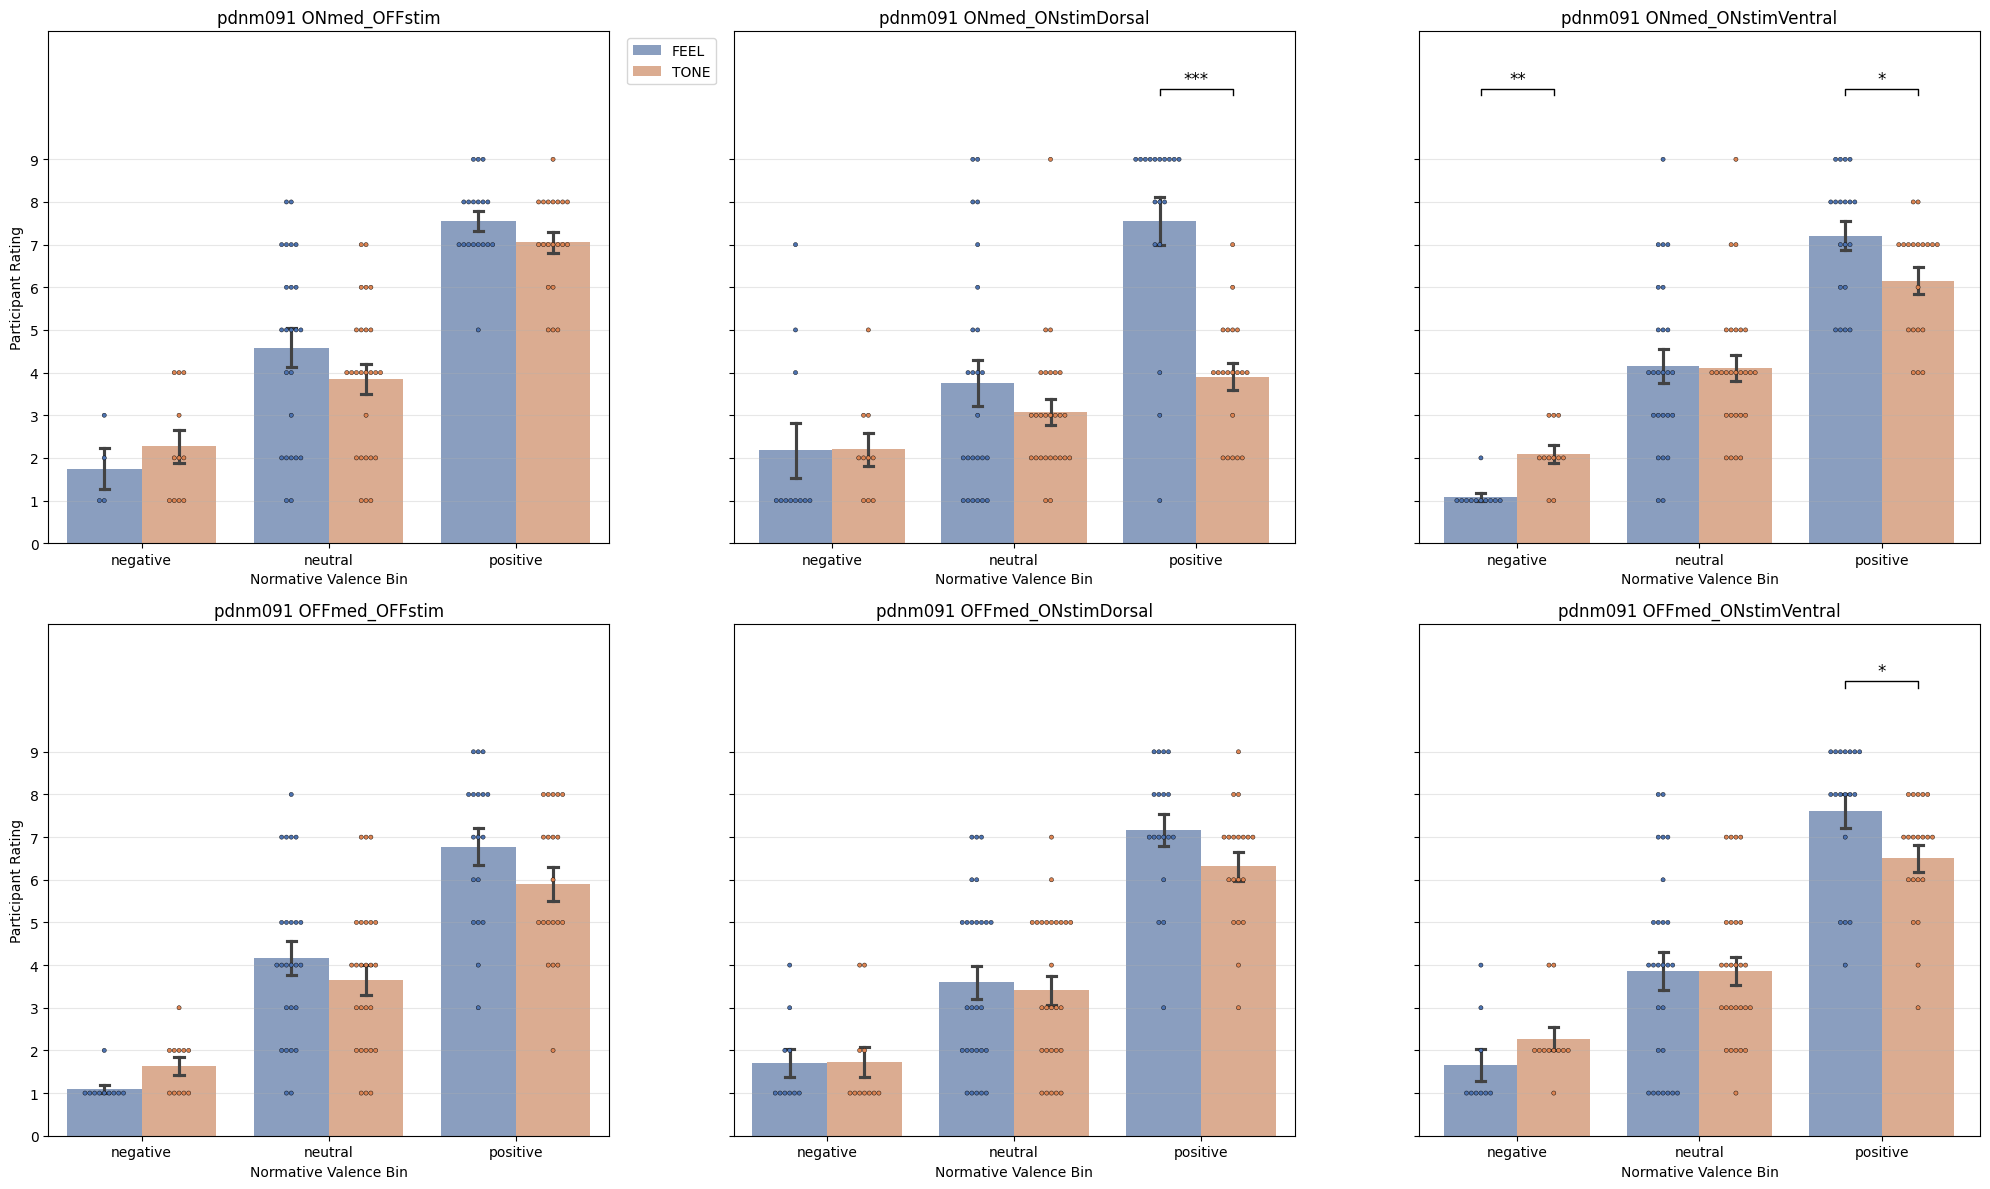

In [48]:
cue_colors = ['#4c72b0', '#dd8452']  # FEEL, TONE
cue_order = ['FEEL', 'TONE']

bar_width = 0.8 / len(cue_order)
cue_offsets = {}
for i, c in enumerate(cue_order):
    cue_offsets[c] = -0.4 + bar_width * (i + 0.5)

y_max = 10
bracket_height = y_max * 0.05

fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for idx, cond in enumerate(condition_order):
    cond_df = plot_df[plot_df['condition'] == cond]

    sns.barplot(
        data=cond_df, x='valence_bin', y='participant_rating', hue='instruction',
        order=bin_labels, hue_order=cue_order, palette=cue_colors,
        errorbar='se', capsize=0.1, alpha=0.7, ax=axes[idx]
    )
    sns.swarmplot(
        data=cond_df, x='valence_bin', y='participant_rating', hue='instruction',
        order=bin_labels, hue_order=cue_order, palette=cue_colors,
        dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[idx]
    )

    cond_results = instruction_results_df[instruction_results_df['condition'] == cond]

    for i in range(len(cond_results)):
        row = cond_results.iloc[i]
        if row['stars'] == '':
            continue

        bin_x = bin_labels.index(row['valence_bin'])
        x1 = bin_x + cue_offsets['FEEL']
        x2 = bin_x + cue_offsets['TONE']

        y = y_max + bracket_height

        axes[idx].plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y],
                        color='black', linewidth=1)
        axes[idx].text((x1 + x2) / 2, y + bracket_height*0.35, row['stars'],
                        ha='center', va='bottom', fontsize=12)

    axes[idx].set_title(f'{subj} {cond}')
    axes[idx].set_xlabel('Normative Valence Bin')
    axes[idx].set_ylabel('Participant Rating' if idx % 3 == 0 else '')
    axes[idx].grid(True, axis='y', alpha=0.3)

axes[0].set_ylim(0, 12)
axes[0].set_yticks(np.arange(0, 10, 1))

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(cue_order)], labels[:len(cue_order)],
               loc='upper left', bbox_to_anchor=(1.02, 1))
for ax in axes[1:]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

C:\Users\fkamdar\AppData\Local\Temp\ipykernel_2640\1061140995.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feel_df['diff_rating'] = feel_df['participant_rating'] - feel_df['normative_rating']
C:\Users\fkamdar\AppData\Local\Temp\ipykernel_2640\1061140995.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tone_df['diff_rating'] = tone_df['participant_rating'] - tone_df['normative_rating']


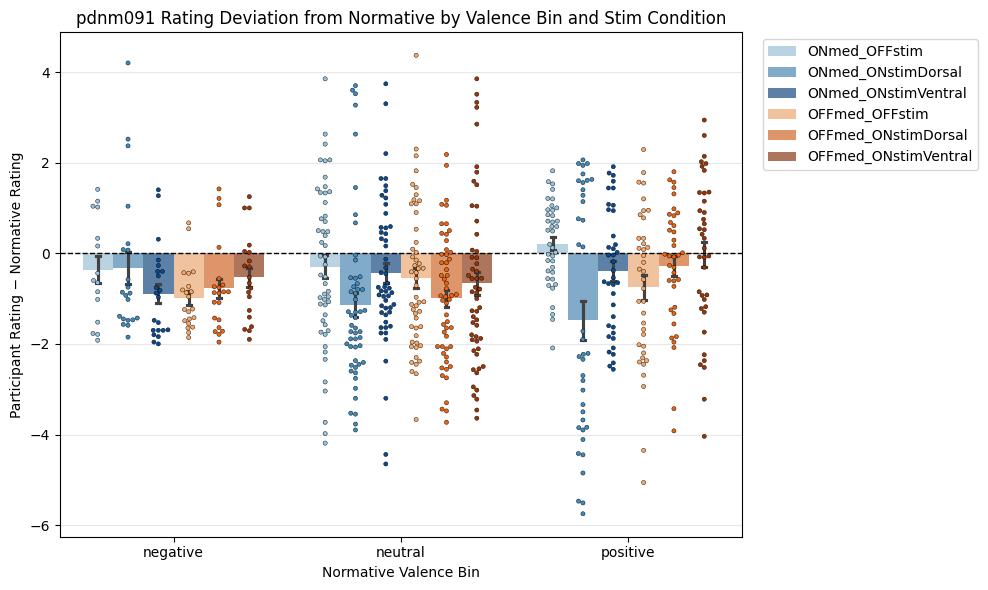

In [52]:
# Difference score: participant rating minus normative rating for each trial
plot_df['diff_rating'] = plot_df['participant_rating'] - plot_df['normative_rating']
feel_df['diff_rating'] = feel_df['participant_rating'] - feel_df['normative_rating']
tone_df['diff_rating'] = tone_df['participant_rating'] - tone_df['normative_rating']

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_df, x='valence_bin', y='diff_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=ax
)
sns.swarmplot(
    data=plot_df, x='valence_bin', y='diff_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=ax
)

ax.axhline(0, color='black', linewidth=1, linestyle='--')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)],
          loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_xlabel('Normative Valence Bin')
ax.set_ylabel('Participant Rating − Normative Rating')
ax.set_title(f'{subj} Rating Deviation from Normative by Valence Bin and Stim Condition')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
diff_results = []

for b in bin_labels:
    bin_df = plot_df[plot_df['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['diff_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['diff_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        diff_results.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

diff_results_df = pd.DataFrame(diff_results)
diff_results_df

,valence_bin,condition_1,condition_2,n1,n2,statistic,p_value,stars
0,negative,ONmed_OFFstim,ONmed_ONstimDorsal,15,21,0.369005,0.712124,
1,negative,ONmed_OFFstim,ONmed_ONstimVentral,15,22,1.237376,0.215947,
2,negative,ONmed_OFFstim,OFFmed_OFFstim,15,21,1.427889,0.153324,
3,negative,ONmed_OFFstim,OFFmed_ONstimDorsal,15,21,1.058884,0.289653,
4,negative,ONmed_OFFstim,OFFmed_ONstimVentral,15,20,0.366667,0.713868,
5,negative,ONmed_ONstimDorsal,ONmed_ONstimVentral,21,22,1.263417,0.206439,
6,negative,ONmed_ONstimDorsal,OFFmed_OFFstim,21,21,1.056541,0.290721,
7,negative,ONmed_ONstimDorsal,OFFmed_ONstimDorsal,21,21,0.553426,0.579972,
8,negative,ONmed_ONstimDorsal,OFFmed_ONstimVentral,21,20,-0.143451,0.885934,
9,negative,ONmed_ONstimVentral,OFFmed_OFFstim,22,21,-0.121482,0.903309,


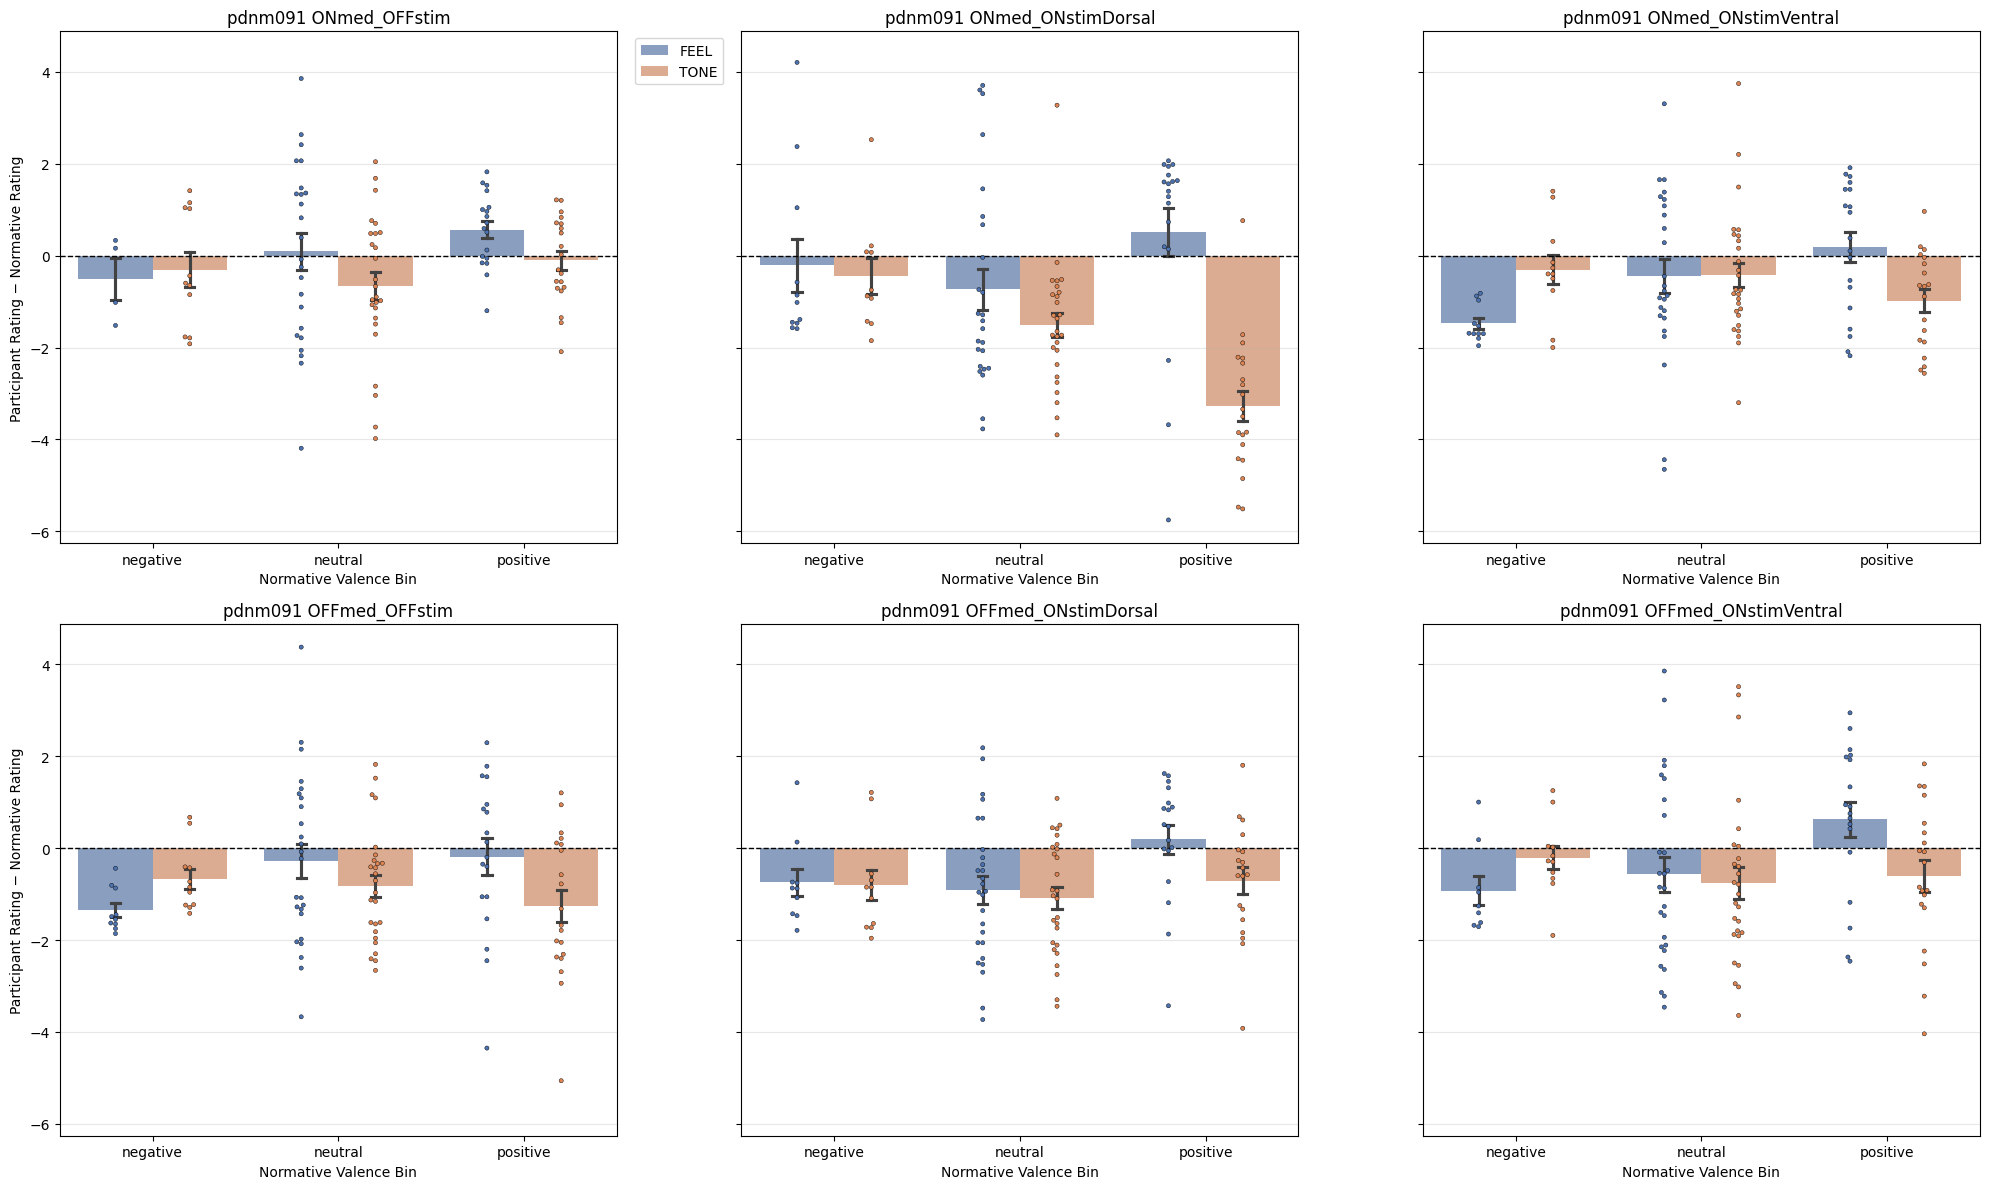

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for idx, cond in enumerate(condition_order):
    cond_df = plot_df[plot_df['condition'] == cond]

    sns.barplot(
        data=cond_df, x='valence_bin', y='diff_rating', hue='instruction',
        order=bin_labels, hue_order=cue_order, palette=cue_colors,
        errorbar='se', capsize=0.1, alpha=0.7, ax=axes[idx]
    )
    sns.swarmplot(
        data=cond_df, x='valence_bin', y='diff_rating', hue='instruction',
        order=bin_labels, hue_order=cue_order, palette=cue_colors,
        dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[idx]
    )

    axes[idx].axhline(0, color='black', linewidth=1, linestyle='--')

    axes[idx].set_title(f'{subj} {cond}')
    axes[idx].set_xlabel('Normative Valence Bin')
    axes[idx].set_ylabel('Participant Rating − Normative Rating' if idx % 3 == 0 else '')
    axes[idx].grid(True, axis='y', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(cue_order)], labels[:len(cue_order)],
               loc='upper left', bbox_to_anchor=(1.02, 1))
for ax in axes[1:]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()